# IFC → Scene Graph → JaxFEM

**Pipeline:**
```
IFC-Datei (IfcOpenShell)
   └─ Bauteil-Parsing (IfcWall, IfcColumn, IfcSlab, ...)
       └─ IFC-Relationship-Analyse
           ├─ IfcRelAggregates          → contains / part_of
           ├─ IfcRelContainedInSpatial  → hosted_in
           ├─ IfcRelAssociatesMaterial  → Material-Mapping
           └─ BBox-Spatial-Analyse      → above / adjacent / near
               └─ NetworkX DiGraph (Scene Graph)
                   ├─ Semantisches Clustering (DBSCAN pro Label)
                   ├─ Feature-Extraktion (Volumen, Höhe, Kompaktheit)
                   ├─ Graphanalyse → Randbedingungen + Lastflächen
                   └─ GMSH Tet4-Netz → JaxFEM Solver
                       └─ Ergebnisse → Scene Graph → LLM-Prompt
```

**Einheiten:** kN, m  
**Referenzen:**
- Poux & Lehtola (2025) — *3D Scene Graphs for Spatial AI + LLMs*
- IFC_FEM_3D.ipynb — BBox-Netz + JaxFEM 3D
- SceneGraph_FEM.ipynb — Synthetischer Scene-Graph-Workflow

## 0 — Importe & Fallbacks

In [1]:
import numpy as onp
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import json
import pathlib
from typing import Dict, List, Tuple, Optional
from scipy.spatial import cKDTree, ConvexHull
from collections import deque

import ifcopenshell
import ifcopenshell.api
import ifcopenshell.geom
import ifcopenshell.util.element
import gmsh
import meshio
import pyvista as pv

from jax_fem.generate_mesh import Mesh
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.utils import save_sol

# ── NetworkX Fallback ────────────────────────────────────────────────
try:
    import networkx as nx
except ModuleNotFoundError:
    class _NodeView:
        def __init__(self, g): self._g = g
        def __iter__(self): return iter(self._g._nodes)
        def __len__(self): return len(self._g._nodes)
        def __getitem__(self, n): return self._g._nodes[n]
        def __call__(self, data=False):
            return list(self._g._nodes.items()) if data else list(self._g._nodes.keys())

    class _EdgeView:
        def __init__(self, g): self._g = g
        def __iter__(self): return iter(self._g._edges)
        def __len__(self): return len(self._g._edges)
        def __getitem__(self, e): return self._g._edges[e]
        def __call__(self, data=False):
            return [(u,v,d) for (u,v),d in self._g._edges.items()] if data else list(self._g._edges.keys())

    class _DiGraph:
        def __init__(self):
            self._nodes, self._edges = {}, {}
            self.nodes = _NodeView(self)
            self.edges = _EdgeView(self)
        def add_node(self, n, **a): self._nodes.setdefault(n, {}).update(a)
        def add_edge(self, u, v, **a):
            self._nodes.setdefault(u, {}); self._nodes.setdefault(v, {})
            self._edges[(u, v)] = dict(a)
        def number_of_nodes(self): return len(self._nodes)
        def number_of_edges(self): return len(self._edges)
        def in_edges(self, n):  return [(u,v) for (u,v) in self._edges if v == n]
        def out_edges(self, n): return [(u,v) for (u,v) in self._edges if u == n]
        def degree(self): return [(n, sum(1 for e in self._edges if n in e)) for n in self._nodes]
        def predecessors(self, n): return [u for (u,v) in self._edges if v == n]
        def successors(self, n): return [v for (u,v) in self._edges if u == n]

    def _weak_cc(G):
        seen, comps = set(), 0
        adj = {n: set() for n in G._nodes}
        for u,v in G._edges: adj[u].add(v); adj[v].add(u)
        for s in G._nodes:
            if s in seen: continue
            comps += 1; stack = [s]; seen.add(s)
            while stack:
                n = stack.pop()
                for nb in adj[n]:
                    if nb not in seen: seen.add(nb); stack.append(nb)
        return comps

    def _spring(G, seed=None):
        ns = list(G._nodes)
        if not ns: return {}
        a = onp.linspace(0, 2*onp.pi, len(ns), endpoint=False)
        return {n: (float(onp.cos(x)), float(onp.sin(x))) for n,x in zip(ns,a)}

    def _draw(G, pos, ax=None, node_color=None, edge_color=None,
              node_size=800, font_size=8, arrows=True, arrowsize=20, width=2, **kw):
        ax = ax or plt.gca()
        ns = list(G.nodes); nc = node_color or ['#aaa']*len(ns)
        xy = onp.array([pos[n] for n in ns], dtype=float)
        ax.scatter(xy[:,0], xy[:,1], s=node_size, c=nc, zorder=3, edgecolors='k', linewidths=.5)
        for n,(x,y) in zip(ns,xy): ax.text(x,y,str(n),ha='center',va='center',fontsize=font_size,zorder=4)
        es = list(G.edges); ec = edge_color or ['#888']*len(es)
        for (u,v),c in zip(es,ec):
            x1,y1=pos[u]; x2,y2=pos[v]
            if arrows: ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
                arrowprops=dict(arrowstyle='-|>',color=c,lw=width,mutation_scale=arrowsize),zorder=2)
            else: ax.plot([x1,x2],[y1,y2],color=c,lw=width,zorder=2)

    def _elabels(G, pos, edge_labels, font_size=7, ax=None, **kw):
        ax = ax or plt.gca()
        for (u,v),lbl in edge_labels.items():
            x=.5*(pos[u][0]+pos[v][0]); y=.5*(pos[u][1]+pos[v][1])
            ax.text(x,y,str(lbl),fontsize=font_size,ha='center',va='center',
                    bbox=dict(facecolor='white',alpha=.7,edgecolor='none'))

    class _NX:
        __version__ = 'fallback'
        DiGraph = _DiGraph
        number_weakly_connected_components = staticmethod(_weak_cc)
        spring_layout = staticmethod(_spring)
        draw_networkx = staticmethod(_draw)
        draw_networkx_edge_labels = staticmethod(_elabels)
    nx = _NX()
    print('Hinweis: networkx nicht installiert — nutze Fallback.')

# ── DBSCAN Fallback ──────────────────────────────────────────────────
try:
    from sklearn.cluster import DBSCAN
except ModuleNotFoundError:
    class DBSCAN:
        def __init__(self, eps=0.5, min_samples=5):
            self.eps, self.min_samples, self.labels_ = eps, min_samples, None
        def fit(self, X):
            X = onp.asarray(X, dtype=float); n = len(X)
            labels = onp.full(n, -1, dtype=int)
            if n == 0: self.labels_ = labels; return self
            nbrs = cKDTree(X).query_ball_point(X, self.eps)
            vis = onp.zeros(n, dtype=bool); cid = 0
            for i in range(n):
                if vis[i]: continue
                vis[i] = True
                if len(nbrs[i]) < self.min_samples: continue
                labels[i] = cid; q = deque(nbrs[i]); seen = set(nbrs[i])
                while q:
                    p = q.popleft()
                    if not vis[p]:
                        vis[p] = True
                        if len(nbrs[p]) >= self.min_samples:
                            for r in nbrs[p]:
                                if r not in seen: q.append(r); seen.add(r)
                    if labels[p] == -1: labels[p] = cid
                cid += 1
            self.labels_ = labels; return self
    print('Hinweis: scikit-learn nicht installiert — nutze DBSCAN-Fallback.')

DATA_DIR = pathlib.Path('../data')
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / 'vtk').mkdir(exist_ok=True)
(DATA_DIR / 'msh').mkdir(exist_ok=True)
pv.OFF_SCREEN = True

print('JAX     :', jax.__version__)
print('gmsh    :', gmsh.__version__)
print('meshio  :', meshio.__version__)
print('pyvista :', pv.__version__)
print('ifcOS   :', ifcopenshell.__version__)
print('networkx:', nx.__version__)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



[04-25 18:38:10][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.


Hinweis: networkx nicht installiert — nutze Fallback.
Hinweis: scikit-learn nicht installiert — nutze DBSCAN-Fallback.
JAX     : 0.6.2
gmsh    : 4.15.2
meshio  : 5.3.5
pyvista : 0.47.3
ifcOS   : 0.8.5
networkx: fallback


## 1 — Konfiguration

In [2]:
# ── IFC-Quelle ────────────────────────────────────────────────────────
# USE_DEMO_MODEL = True  → erzeugt synthetisches IFC-Modell
# USE_DEMO_MODEL = False → liest IFC_PATH ein
USE_DEMO_MODEL = True
IFC_PATH = str(DATA_DIR / 'ifc_fem_3d.ifc')   # eigene Datei hier

# ── Netz ─────────────────────────────────────────────────────────────
MESH_SIZE = 0.25       # m — Tet4-Elementgröße

# ── Material-Fallback (falls kein Pset_MaterialMechanical im IFC) ────
E_DEFAULT    = 30_000.0    # kN/m²  (C25/30)
NU_DEFAULT   = 0.2
GAMMA_BETON  = 25.0        # kN/m³

# ── Lasten ───────────────────────────────────────────────────────────
Q_NUTZLAST   = 5.0         # kN/m²

# ── Scene-Graph-Parameter ────────────────────────────────────────────
DBSCAN_EPS         = 0.6   # m — Clustering-Radius
DBSCAN_MIN_SAMPLES = 5
REL_THRESHOLD      = 5.0   # m — Max. Distanz für Graphkante
ADJ_TOLERANCE      = 0.05  # m — BBox-Berührungs-Toleranz

# ── Semantisches Mapping: IFC-Klasse → Label ─────────────────────────
IFC_LABEL_MAP = {
    'IfcWall'          : 'wall',
    'IfcWallStandardCase': 'wall',
    'IfcColumn'        : 'column',
    'IfcSlab'          : 'slab',
    'IfcBeam'          : 'beam',
    'IfcFooting'       : 'footing',
    'IfcPile'          : 'pile',
}

print(f'Elementgröße  : {MESH_SIZE} m')
print(f'Nutzlast      : {Q_NUTZLAST} kN/m²')
print(f'DBSCAN eps    : {DBSCAN_EPS} m')
print(f'Demo-Modell   : {USE_DEMO_MODEL}')

Elementgröße  : 0.25 m
Nutzlast      : 5.0 kN/m²
DBSCAN eps    : 0.6 m
Demo-Modell   : True


## 2 — IFC laden

Zwei Modi:
- **Demo-Modell:** Erzeugt ein synthetisches IFC (2 Wände + 1 Stütze + Decke) mit `Pset_MaterialMechanical`
- **Eigene Datei:** `USE_DEMO_MODEL = False`, `IFC_PATH` setzen

Das Parsing extrahiert für jedes Bauteil:
1. IFC-Klasse → semantisches Label
2. BBox aus OBB-Settings oder Vertex-Scan via `ifcopenshell.geom`
3. E-Modul + Querdehnzahl aus `Pset_MaterialMechanical`
4. Synthethische Punktwolke (Gleichverteilung in BBox) für DBSCAN

In [3]:
def _box_vf(x0, y0, z0, dx, dy, dz):
    """Vertices + Faces einer Quader-Geometrie."""
    v = [(x0,y0,z0),(x0+dx,y0,z0),(x0+dx,y0+dy,z0),(x0,y0+dy,z0),
         (x0,y0,z0+dz),(x0+dx,y0,z0+dz),(x0+dx,y0+dy,z0+dz),(x0,y0+dy,z0+dz)]
    f = [(0,1,2),(0,2,3),(4,6,5),(4,7,6),(0,1,5),(0,5,4),
         (2,3,7),(2,7,6),(0,3,7),(0,7,4),(1,2,6),(1,6,5)]
    return v, f


def create_demo_ifc(out_path: str) -> str:
    """Erzeugt ein synthetisches IFC4-Modell und speichert es."""
    model   = ifcopenshell.api.run('project.create_file', version='IFC4')
    project = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcProject',
                                   name='Demo_SceneGraph')
    ifcopenshell.api.run('unit.assign_unit', model,
                         length={'is_metric': True, 'raw': 'METRES'})
    ctx  = ifcopenshell.api.run('context.add_context', model, context_type='Model')
    body = ifcopenshell.api.run('context.add_context', model, context_type='Model',
                                context_identifier='Body',
                                target_view='MODEL_VIEW', parent=ctx)
    site     = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcSite',
                                    name='Site')
    building = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcBuilding',
                                    name='Gebaeude')
    storey   = ifcopenshell.api.run('root.create_entity', model,
                                    ifc_class='IfcBuildingStorey', name='EG')
    ifcopenshell.api.run('aggregate.assign_object', model,
                         products=[site],     relating_object=project)
    ifcopenshell.api.run('aggregate.assign_object', model,
                         products=[building], relating_object=site)
    ifcopenshell.api.run('aggregate.assign_object', model,
                         products=[storey],   relating_object=building)

    # (ifc_class, name, x0, y0, z0, dx, dy, dz, E_kNm2, nu)
    BAUTEILE = [
        ('IfcWall',   'Wand_A',    0.0, 0.0, 0.0, 4.0, 0.2, 2.8, 30_000.0, 0.2),
        ('IfcWall',   'Wand_B',    0.0, 3.8, 0.0, 4.0, 0.2, 2.8, 30_000.0, 0.2),
        ('IfcColumn', 'Stuetze_M', 1.9, 1.9, 0.0, 0.2, 0.2, 2.8, 35_000.0, 0.2),
        ('IfcSlab',   'Decke_D1',  0.0, 0.0, 2.8, 4.0, 4.0, 0.2, 30_000.0, 0.2),
    ]

    for ifc_class, name, x0, y0, z0, dx, dy, dz, E_val, nu_val in BAUTEILE:
        elem = ifcopenshell.api.run('root.create_entity', model,
                                    ifc_class=ifc_class, name=name)
        v, f = _box_vf(x0, y0, z0, dx, dy, dz)
        rep  = ifcopenshell.api.run('geometry.add_mesh_representation', model,
                                    context=body, vertices=[v], faces=[f])
        ifcopenshell.api.run('geometry.assign_representation', model,
                             product=elem, representation=rep)
        ifcopenshell.api.run('spatial.assign_container', model,
                             relating_structure=storey, products=[elem])
        mat  = ifcopenshell.api.run('material.add_material', model,
                                    name=f'C25_30_{name}')
        ifcopenshell.api.run('material.assign_material', model,
                             products=[elem], material=mat)
        pset = ifcopenshell.api.run('pset.add_pset', model, product=elem,
                                    name='Pset_MaterialMechanical')
        ifcopenshell.api.run('pset.edit_pset', model, pset=pset,
            properties={'YoungModulus': E_val, 'PoissonRatio': nu_val,
                        'MassDensity': GAMMA_BETON / 9.81 * 1000})
    model.write(out_path)
    return out_path


if USE_DEMO_MODEL:
    ifc_path = str(DATA_DIR / 'ifc_scene_graph.ifc')
    create_demo_ifc(ifc_path)
    print(f'Demo-IFC erzeugt: {ifc_path}')
else:
    ifc_path = IFC_PATH
    print(f'Lade IFC: {ifc_path}')

Demo-IFC erzeugt: ../data/ifc_scene_graph.ifc


## 3 — IFC parsen: Bauteile + BBox + Material

Für jedes tragwerksrelevante Element wird:
1. Das semantische Label aus `IFC_LABEL_MAP` abgeleitet
2. Die Bounding Box aus den Mesh-Vertices (via `ifcopenshell.geom`) berechnet
3. `Pset_MaterialMechanical.YoungModulus` / `PoissonRatio` ausgelesen
4. Eine synthetische Punktwolke für das DBSCAN-Clustering erzeugt

In [4]:
def bbox_from_vertices(verts: onp.ndarray) -> Tuple[onp.ndarray, onp.ndarray]:
    """Achsenparallele BBox aus Vertex-Array (N, 3)."""
    return verts.min(axis=0), verts.max(axis=0)


def get_element_bbox(ifc_model, elem) -> Optional[Tuple[onp.ndarray, onp.ndarray]]:
    """BBox eines IFC-Elements via ifcopenshell.geom."""
    try:
        settings = ifcopenshell.geom.settings()
        settings.set(settings.USE_WORLD_COORDS, True)
        shape   = ifcopenshell.geom.create_shape(settings, elem)
        verts   = onp.array(shape.geometry.verts).reshape(-1, 3)
        return bbox_from_vertices(verts)
    except Exception:
        return None


def read_material_props(elem, e_default=E_DEFAULT, nu_default=NU_DEFAULT):
    """YoungModulus + PoissonRatio aus Pset_MaterialMechanical."""
    psets = ifcopenshell.util.element.get_psets(elem)
    mech  = psets.get('Pset_MaterialMechanical', {})
    E  = mech.get('YoungModulus',  e_default)
    nu = mech.get('PoissonRatio',  nu_default)
    return float(E), float(nu)


rng = onp.random.default_rng(42)

def sample_box_uniform(bmin, bmax, n_target: int = 800) -> onp.ndarray:
    """Gleichmäßige Punktwolke in einer BBox (für DBSCAN)."""
    vol  = float(onp.prod(bmax - bmin))
    n    = max(int(n_target * min(vol / 3.0, 1.0) + 50), 50)
    return onp.column_stack([
        rng.uniform(bmin[0], bmax[0], n),
        rng.uniform(bmin[1], bmax[1], n),
        rng.uniform(bmin[2], bmax[2], n),
    ])


# ── Hauptparsing ─────────────────────────────────────────────────────
ifc_model = ifcopenshell.open(ifc_path)

elements_raw = []   # Rohdata pro Bauteil
all_pts      = []   # Punktwolke (für DBSCAN)
all_labels   = []   # Semantisches Label pro Punkt

ifc_classes_to_parse = list(IFC_LABEL_MAP.keys())

for ifc_class in ifc_classes_to_parse:
    for elem in ifc_model.by_type(ifc_class):
        label = IFC_LABEL_MAP[ifc_class]
        bbox  = get_element_bbox(ifc_model, elem)
        if bbox is None:
            print(f'  SKIP {elem.Name} — keine Geometrie')
            continue
        bmin, bmax = bbox
        dims = bmax - bmin
        if onp.prod(dims) < 1e-6:
            print(f'  SKIP {elem.Name} — degenerierte BBox')
            continue
        E, nu = read_material_props(elem)
        pts   = sample_box_uniform(bmin, bmax)
        all_pts.append(pts)
        all_labels.extend([label] * len(pts))
        elements_raw.append({
            'name'     : elem.Name or elem.GlobalId,
            'guid'     : elem.GlobalId,
            'ifc_class': ifc_class,
            'label'    : label,
            'bbox_min' : bmin,
            'bbox_max' : bmax,
            'dims'     : dims,
            'origin'   : bmin.copy(),
            'centroid' : 0.5 * (bmin + bmax),
            'E'        : E,
            'nu'       : nu,
        })

cloud_pts    = onp.vstack(all_pts)
cloud_labels = onp.array(all_labels)

print(f'\n{len(elements_raw)} Bauteile aus IFC geparst:')
print(f'{"Name":20s}  {"Klasse":18s}  {"Label":8s}  '
      f'{"BBox [m]"}   E [kN/m²]')
print('-' * 75)
for e in elements_raw:
    d = e['dims']
    print(f'  {e["name"]:18s}  {e["ifc_class"]:18s}  {e["label"]:8s}  '
          f'{d[0]:.2f}×{d[1]:.2f}×{d[2]:.2f}   {e["E"]:.0f}')

print(f'\nPunktwolke: {len(cloud_pts)} Punkte ({len(onp.unique(cloud_labels))} Labels)')


4 Bauteile aus IFC geparst:
Name                  Klasse              Label     BBox [m]   E [kN/m²]
---------------------------------------------------------------------------
  Wand_A              IfcWall             wall      4.00×0.20×2.80   30000
  Wand_B              IfcWall             wall      4.00×0.20×2.80   30000
  Stuetze_M           IfcColumn           column    0.20×0.20×2.80   35000
  Decke_D1            IfcSlab             slab      4.00×4.00×0.20   30000

Punktwolke: 2223 Punkte (3 Labels)


### Visualisierung: BBox-Wireframe + Abmessungen

In [ ]:
# Visualisierung: BBox-Übersicht als 3D-Wireframe + Tabelle
fig = plt.figure(figsize=(14, 5))

# Links: 3D-Wireframe aller BBoxen
ax3d = fig.add_subplot(1, 2, 1, projection='3d')
_colors = [COLOR_MAP.get(e['label'], 'gray') for e in elements_raw]
for e, col in zip(elements_raw, _colors):
    bmin, bmax = e['bbox_min'], e['bbox_max']
    # 12 Kanten eines Quaders
    _verts = [
        [bmin[0],bmin[1],bmin[2]], [bmax[0],bmin[1],bmin[2]],
        [bmax[0],bmax[1],bmin[2]], [bmin[0],bmax[1],bmin[2]],
        [bmin[0],bmin[1],bmax[2]], [bmax[0],bmin[1],bmax[2]],
        [bmax[0],bmax[1],bmax[2]], [bmin[0],bmax[1],bmax[2]],
    ]
    _edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),
              (0,4),(1,5),(2,6),(3,7)]
    for i1, i2 in _edges:
        ax3d.plot3D(*zip(_verts[i1], _verts[i2]), color=col, lw=1.2)
    cx, cy, cz = e['centroid']
    ax3d.text(cx, cy, cz, e['name'], fontsize=6, ha='center', color='black')
ax3d.set_xlabel('x [m]'); ax3d.set_ylabel('y [m]'); ax3d.set_zlabel('z [m]')
ax3d.set_title('IFC-Bauteile — 3D BBoxen', fontsize=10)

# Rechts: Balken — Bauteil-Abmessungen (dx, dy, dz) gestapelt
ax2 = fig.add_subplot(1, 2, 2)
names = [e['name'] for e in elements_raw]
dx = [e['dims'][0] for e in elements_raw]
dy = [e['dims'][1] for e in elements_raw]
dz = [e['dims'][2] for e in elements_raw]
x_pos = onp.arange(len(names))
w = 0.25
ax2.bar(x_pos - w, dx, w, label='dx [m]', color='#4a90d9')
ax2.bar(x_pos,     dy, w, label='dy [m]', color='#e05c5c')
ax2.bar(x_pos + w, dz, w, label='dz [m]', color='#5cb85c')
ax2.set_xticks(x_pos); ax2.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('Abmessung [m]'); ax2.set_title('Bauteil-Abmessungen', fontsize=10)
ax2.legend(); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('IFC-Parsing — Bauteile & BBoxen', fontsize=12)
plt.tight_layout()
plt.show()

## 4 — Visualisierung der semantischen Punktwolke

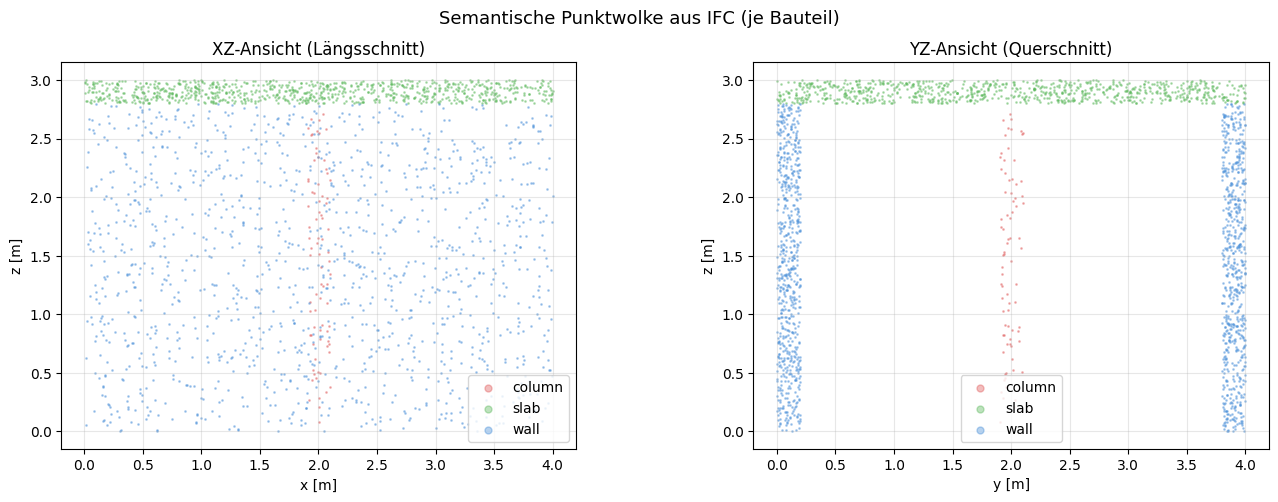

In [5]:
COLOR_MAP = {
    'wall'   : '#4a90d9',
    'column' : '#e05c5c',
    'slab'   : '#5cb85c',
    'beam'   : '#f0ad4e',
    'footing': '#9b59b6',
    'pile'   : '#1abc9c',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lbl in onp.unique(cloud_labels):
    mask = (cloud_labels == lbl)
    pts  = cloud_pts[mask]
    c    = COLOR_MAP.get(lbl, 'gray')
    axes[0].scatter(pts[:,0], pts[:,2], s=1, c=c, alpha=0.4, label=lbl)
    axes[1].scatter(pts[:,1], pts[:,2], s=1, c=c, alpha=0.4, label=lbl)

for ax, xl, ttl in [
    (axes[0], 'x [m]', 'XZ-Ansicht (Längsschnitt)'),
    (axes[1], 'y [m]', 'YZ-Ansicht (Querschnitt)'),
]:
    ax.set_xlabel(xl); ax.set_ylabel('z [m]')
    ax.set_title(ttl); ax.set_aspect('equal')
    ax.legend(markerscale=5); ax.grid(True, alpha=0.3)

plt.suptitle('Semantische Punktwolke aus IFC (je Bauteil)', fontsize=13)
plt.tight_layout()
plt.show()

## 5 — IFC-Relationship-Analyse

Drei Quellen für Graphkanten:

| IFC-Relationship | Kanten-Typ | Bedeutung |
|---|---|---|
| `IfcRelAggregates` | `part_of` / `contains` | Hierarchische Zerlegung |
| `IfcRelContainedInSpatialStructure` | `hosted_in` | Stockwerk-Zuordnung |
| `IfcRelAssociatesMaterial` | `shared_material` | Gleiches Material |
| BBox-Spatial (Schritt 6) | `above/adjacent/near` | Geometrische Lage |

In [6]:
def extract_ifc_relationships(ifc_model, elements_raw: List[Dict]) -> List[Tuple]:
    """Liest IFC-Relationships aus und gibt (name_a, name_b, rel_type) zurück."""
    # GUID → Name-Index für schnelle Suche
    guid_map = {e['guid']: e['name'] for e in elements_raw}
    rels = []

    # 1. IfcRelAggregates: hierarchische Zerlegung
    for rel in ifc_model.by_type('IfcRelAggregates'):
        whole = rel.RelatingObject
        if not hasattr(rel, 'RelatedObjects'): continue
        for part in rel.RelatedObjects:
            w_name = guid_map.get(getattr(whole, 'GlobalId', None))
            p_name = guid_map.get(getattr(part,  'GlobalId', None))
            if w_name and p_name:
                rels.append((w_name, p_name, 'contains'))

    # 2. IfcRelContainedInSpatialStructure: Stockwerk-Zuordnung
    #    Alle Bauteile im selben Stockwerk erhalten eine gemeinsame Kante
    storey_elements: Dict[str, List[str]] = {}
    for rel in ifc_model.by_type('IfcRelContainedInSpatialStructure'):
        storey = rel.RelatingStructure
        storey_name = getattr(storey, 'Name', str(storey))
        if not hasattr(rel, 'RelatedElements'): continue
        for elem in rel.RelatedElements:
            name = guid_map.get(getattr(elem, 'GlobalId', None))
            if name:
                storey_elements.setdefault(storey_name, []).append(name)

    # 3. IfcRelAssociatesMaterial: gemeinsames Material → Kante
    mat_elements: Dict[str, List[str]] = {}
    for rel in ifc_model.by_type('IfcRelAssociatesMaterial'):
        mat = rel.RelatingMaterial
        mat_name = getattr(mat, 'Name', str(mat))
        if not hasattr(rel, 'RelatedObjects'): continue
        for elem in rel.RelatedObjects:
            name = guid_map.get(getattr(elem, 'GlobalId', None))
            if name:
                mat_elements.setdefault(mat_name, []).append(name)

    for mat_name, names in mat_elements.items():
        for i in range(len(names)):
            for j in range(i+1, len(names)):
                rels.append((names[i], names[j], 'shared_material'))

    return rels, storey_elements


ifc_rels, storey_map = extract_ifc_relationships(ifc_model, elements_raw)

print('IFC-Relationships:')
if ifc_rels:
    for a, b, r in ifc_rels:
        print(f'  {a:20s}  --[{r}]-->  {b}')
else:
    print('  (keine direkten IFC-Relationships zwischen Bauteilen)')

print('\nStockwerk-Zuordnung:')
for storey, names in storey_map.items():
    print(f'  {storey}: {names}')

IFC-Relationships:
  (keine direkten IFC-Relationships zwischen Bauteilen)

Stockwerk-Zuordnung:
  EG: ['Wand_B', 'Decke_D1', 'Wand_A', 'Stuetze_M']


### Visualisierung: Relationship-Typen + Stockwerk

In [ ]:
# Visualisierung: IFC-Relationship-Matrix + Balken Relationship-Typen
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Links: Relationship-Typen (Balken)
all_rel_cts: Dict[str, int] = {}
for _, _, r in relationships if 'relationships' in dir() else []:
    all_rel_cts[r] = all_rel_cts.get(r, 0) + 1
# Vorschau auf bereits bekannte ifc_rels
for _, _, r in ifc_rels:
    lbl = f'ifc_{r}'
    all_rel_cts[lbl] = all_rel_cts.get(lbl, 0) + 1

if all_rel_cts:
    ax = axes[0]
    ax.barh(list(all_rel_cts.keys()), list(all_rel_cts.values()),
            color=['#ff7f0e' if 'ifc' in k else '#4a90d9' for k in all_rel_cts])
    ax.set_xlabel('Anzahl'); ax.set_title('IFC-Relationship-Typen', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'Keine IFC-Rels\n(nur geometrisch)', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=11, color='gray')
    axes[0].set_title('IFC-Relationship-Typen', fontsize=10)

# Rechts: Stockwerk-Belegungs-Balken
ax2 = axes[1]
storey_names = list(storey_map.keys())
storey_counts = [len(v) for v in storey_map.values()]
if storey_names:
    ax2.bar(storey_names, storey_counts, color='#9b59b6')
    ax2.set_ylabel('Anzahl Bauteile')
    for i, (n, c) in enumerate(zip(storey_names, storey_counts)):
        ax2.text(i, c + 0.05, str(c), ha='center', va='bottom', fontsize=9)
else:
    ax2.text(0.5, 0.5, 'Keine Stockwerk-Daten', ha='center', va='center',
             transform=ax2.transAxes, color='gray')
ax2.set_title('Bauteile pro Stockwerk', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('IFC-Relationship-Analyse', fontsize=12)
plt.tight_layout()
plt.show()

## 6 — Semantisches Clustering (DBSCAN pro Label)

Analog Poux & Lehtola (2025), Step 4:
Für jedes semantisches Label wird DBSCAN auf die zugehörigen Punkte angewendet,
um diskrete Objekt-Instanzen zu ermitteln.  
Anschließend werden die geclusterten Objekte zurück auf die exakten IFC-BBoxen gesnapped.

In [7]:
def cluster_semantic_objects(
    pts: onp.ndarray,
    labels: onp.ndarray,
    eps: float = DBSCAN_EPS,
    min_samples: int = DBSCAN_MIN_SAMPLES,
) -> Dict:
    objects = {}
    for lbl in onp.unique(labels):
        mask   = (labels == lbl)
        l_pts  = pts[mask]
        if len(l_pts) < min_samples:
            continue
        cl = DBSCAN(eps=eps, min_samples=min_samples).fit(l_pts)
        for cid in onp.unique(cl.labels_):
            if cid == -1:
                continue
            c_pts = l_pts[cl.labels_ == cid]
            key   = f'{lbl}_{cid}'
            objects[key] = {
                'points'        : c_pts,
                'centroid'      : c_pts.mean(axis=0),
                'bounds_min'    : c_pts.min(axis=0),
                'bounds_max'    : c_pts.max(axis=0),
                'semantic_label': str(lbl),
                'point_count'   : len(c_pts),
            }
    return objects


def snap_to_ifc_bboxes(objects: Dict, elements_raw: List[Dict]) -> Dict:
    """Ersetzt Cluster-BBoxen durch exakte IFC-BBoxen + Material-Properties."""
    used = set()
    for name, obj in objects.items():
        lbl       = obj['semantic_label']
        centroid  = onp.asarray(obj['centroid'], dtype=float)
        candidates = [
            (i, e) for i, e in enumerate(elements_raw)
            if e['label'] == lbl and i not in used
        ]
        if not candidates:
            continue
        best_i, best = min(
            candidates,
            key=lambda ie: onp.linalg.norm(
                centroid - ie[1]['centroid']
            )
        )
        used.add(best_i)
        obj['bounds_min'] = best['bbox_min'].astype(float).copy()
        obj['bounds_max'] = best['bbox_max'].astype(float).copy()
        obj['centroid']   = 0.5 * (obj['bounds_min'] + obj['bounds_max'])
        obj['dims']       = best['dims'].astype(float).copy()
        obj['origin']     = best['origin'].astype(float).copy()
        obj['E']          = best['E']
        obj['nu']         = best['nu']
        obj['ifc_name']   = best['name']
        obj['ifc_guid']   = best['guid']
        obj['ifc_class']  = best['ifc_class']
    return objects


objects = cluster_semantic_objects(cloud_pts, cloud_labels)
objects = snap_to_ifc_bboxes(objects, elements_raw)

print(f'{len(objects)} Objekte nach Clustering + IFC-Snap:')
print(f'{"Key":18s}  {"IFC-Name":15s}  {"Label":8s}  '
      f'{"BBox [m]"}          E [kN/m²]')
print('-' * 75)
for k, obj in objects.items():
    d = obj['bounds_max'] - obj['bounds_min']
    print(f'  {k:16s}  {obj.get("ifc_name","?"):15s}  '
          f'{obj["semantic_label"]:8s}  '
          f'{d[0]:.2f}×{d[1]:.2f}×{d[2]:.2f}   '
          f'{obj.get("E", E_DEFAULT):.0f}')

4 Objekte nach Clustering + IFC-Snap:
Key                 IFC-Name         Label     BBox [m]          E [kN/m²]
---------------------------------------------------------------------------
  column_0          Stuetze_M        column    0.20×0.20×2.80   35000
  slab_0            Decke_D1         slab      4.00×4.00×0.20   30000
  wall_0            Wand_A           wall      4.00×0.20×2.80   30000
  wall_1            Wand_B           wall      4.00×0.20×2.80   30000


### Visualisierung: DBSCAN-Cluster-Instanzen

In [ ]:
# Visualisierung: DBSCAN-Clustering-Ergebnis — Cluster-Instanzen farbig
CLUSTER_PALETTE = [
    '#e41a1c','#377eb8','#4daf4a','#984ea3',
    '#ff7f00','#a65628','#f781bf','#999999',
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster-IDs pro Punkt zurückrechnen (aus objects-Dict)
cluster_color_arr = onp.full(len(cloud_pts), '#cccccc', dtype=object)
cluster_id_arr    = onp.full(len(cloud_pts), -1, dtype=int)
for ci, (key, obj) in enumerate(objects.items()):
    pts_obj = obj['points']
    tree    = cKDTree(pts_obj)
    dists, _ = tree.query(cloud_pts, k=1, distance_upper_bound=DBSCAN_EPS * 0.5)
    mask = dists < DBSCAN_EPS * 0.5
    cluster_color_arr[mask] = CLUSTER_PALETTE[ci % len(CLUSTER_PALETTE)]
    cluster_id_arr[mask]    = ci

for ax, x_col, z_col, xlabel, title in [
    (axes[0], 0, 2, 'x [m]', 'XZ — Clustering-Instanzen'),
    (axes[1], 1, 2, 'y [m]', 'YZ — Clustering-Instanzen'),
]:
    for ci, (key, obj) in enumerate(objects.items()):
        col = CLUSTER_PALETTE[ci % len(CLUSTER_PALETTE)]
        c_pts = obj['points']
        ax.scatter(c_pts[:, x_col], c_pts[:, z_col],
                   s=1, c=col, alpha=0.5, label=f'{key} ({obj["semantic_label"]})')
        cx = obj['centroid'][x_col]; cz = obj['centroid'][z_col]
        ax.scatter(cx, cz, s=80, c=col, edgecolors='black', zorder=5)
        ax.text(cx, cz + 0.05, key, fontsize=7, ha='center')
    ax.set_xlabel(xlabel); ax.set_ylabel('z [m]')
    ax.set_title(title, fontsize=10); ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
axes[0].legend(markerscale=4, fontsize=7, loc='upper right')

plt.suptitle(f'DBSCAN-Clustering: {len(objects)} Objekt-Instanzen', fontsize=12)
plt.tight_layout()
plt.show()

## 7 — Objekt-Feature-Extraktion

Analog Poux & Lehtola (2025), Step 6:
Volumen (BBox), Oberfläche (konvexe Hülle), Kompaktheit, Höhe.

In [8]:
def surface_area(pts: onp.ndarray) -> float:
    try: return float(ConvexHull(pts).area)
    except Exception: return 0.0


def compute_features(objects: Dict) -> Dict:
    features = {}
    for name, obj in objects.items():
        dims    = obj['bounds_max'] - obj['bounds_min']
        vol     = float(onp.prod(dims))
        sa      = surface_area(obj['points'])
        compact = (sa**3) / (36 * onp.pi * vol**2) if vol > 0 else 0.0
        features[name] = {
            'volume'        : vol,
            'surface_area'  : sa,
            'compactness'   : compact,
            'height'        : float(dims[2]),
            'aspect_ratio'  : float(max(dims) / (min(dims) + 1e-9)),
            'semantic_label': obj['semantic_label'],
            'centroid'      : obj['centroid'],
            'point_density' : obj['point_count'] / vol if vol > 0 else 0.0,
        }
    return features


features = compute_features(objects)

print(f'{"Objekt":18s}  {"Vol [m³]":>10s}  '
      f'{"Höhe [m]":>8s}  {"Komp."}  Aspekt')
print('-' * 60)
for n, f in features.items():
    print(f'  {n:16s}  {f["volume"]:>10.3f}  '
          f'{f["height"]:>8.2f}  {f["compactness"]:6.2f}  '
          f'{f["aspect_ratio"]:5.1f}')

Objekt                Vol [m³]  Höhe [m]  Komp.  Aspekt
------------------------------------------------------------
  column_0               0.112      2.80    2.51   14.0
  slab_0                 3.200      0.20   30.76   20.0
  wall_0                 2.240      2.80   21.93   20.0
  wall_1                 2.240      2.80   22.82   20.0


### Visualisierung: Feature-Profil

In [ ]:
# Visualisierung: Feature-Profil pro Objekt (Radar/Balken)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

names_f = list(features.keys())
cols_f  = [COLOR_MAP.get(features[n]['semantic_label'], '#aaa') for n in names_f]

# Volumen
axes[0].bar(names_f, [features[n]['volume'] for n in names_f], color=cols_f)
axes[0].set_title('Volumen [m³]', fontsize=10)
axes[0].set_ylabel('m³'); axes[0].grid(axis='y', alpha=0.3)
for i, n in enumerate(names_f):
    axes[0].text(i, features[n]['volume'] + 0.02,
                 f'{features[n]["volume"]:.2f}', ha='center', fontsize=8)

# Höhe
axes[1].bar(names_f, [features[n]['height'] for n in names_f], color=cols_f)
axes[1].set_title('Höhe [m]', fontsize=10)
axes[1].set_ylabel('m'); axes[1].grid(axis='y', alpha=0.3)
for i, n in enumerate(names_f):
    axes[1].text(i, features[n]['height'] + 0.02,
                 f'{features[n]["height"]:.2f}', ha='center', fontsize=8)

# Kompaktheit + Aspektverhältnis (Doppelachse)
ax_k = axes[2]
ax_a = ax_k.twinx()
x_pos = onp.arange(len(names_f))
ax_k.bar(x_pos - 0.2, [features[n]['compactness'] for n in names_f],
         0.35, color=cols_f, alpha=0.8, label='Kompaktheit')
ax_a.bar(x_pos + 0.2, [features[n]['aspect_ratio'] for n in names_f],
         0.35, color=cols_f, alpha=0.4, label='Aspektverhältnis', hatch='//')
ax_k.set_xticks(x_pos); ax_k.set_xticklabels(names_f, rotation=15, ha='right', fontsize=8)
ax_k.set_ylabel('Kompaktheit'); ax_a.set_ylabel('Aspektverhältnis')
ax_k.set_title('Kompaktheit / Aspektverhältnis', fontsize=10)
ax_k.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
axes[2].legend(handles=[
    Patch(facecolor='gray', alpha=0.8, label='Kompaktheit'),
    Patch(facecolor='gray', alpha=0.4, hatch='//', label='Aspektverhältnis'),
], fontsize=8, loc='upper left')

for ax in axes: ax.set_xticklabels(
    [n for n in names_f], rotation=15, ha='right', fontsize=8)
plt.suptitle('Objekt-Features aus Punktwolke + BBox', fontsize=12)
plt.tight_layout()
plt.show()

## 8 — Räumliche Beziehungsanalyse

Drei-Stufen-Algorithmus auf BBox-Basis:

1. **Vertikal:** `above`/`below` bei Höhenunterschied > 0,5 m
2. **Containment:** Ist ein Objekt vollständig in einem anderen?
3. **Adjacency:** Berühren sich die BBoxen (Toleranz `ADJ_TOLERANCE`)?
4. **Fallback:** `near` bei Distanz < `REL_THRESHOLD`

IFC-Relationships aus Schritt 5 werden ergänzt.

In [9]:
def is_contained(bmin1, bmax1, bmin2, bmax2) -> bool:
    return bool(onp.all(bmin1 >= bmin2) and onp.all(bmax1 <= bmax2))


def are_adjacent(bmin1, bmax1, bmin2, bmax2, tol=ADJ_TOLERANCE) -> bool:
    for ax in range(3):
        if (abs(bmax1[ax] - bmin2[ax]) < tol or
                abs(bmax2[ax] - bmin1[ax]) < tol):
            return True
    return False


def classify_spatial_rel(obj1, obj2, threshold=REL_THRESHOLD) -> Optional[str]:
    d = onp.linalg.norm(obj1['centroid'] - obj2['centroid'])
    if d > threshold: return None
    bmin1, bmax1 = obj1['bounds_min'], obj1['bounds_max']
    bmin2, bmax2 = obj2['bounds_min'], obj2['bounds_max']
    dz = float(obj1['centroid'][2] - obj2['centroid'][2])
    if abs(dz) > 0.5: return 'above' if dz > 0 else 'below'
    if is_contained(bmin1, bmax1, bmin2, bmax2): return 'inside'
    if is_contained(bmin2, bmax2, bmin1, bmax1): return 'contains'
    if are_adjacent(bmin1, bmax1, bmin2, bmax2): return 'adjacent'
    return 'near'


def compute_all_relationships(objects: Dict, ifc_rels: List) -> List[Tuple]:
    """Kombiniert geometrische + IFC-Relationships."""
    # Lookup: IFC-Name → Cluster-Key
    name_to_key = {obj.get('ifc_name', k): k for k, obj in objects.items()}

    rels = []
    seen = set()

    # IFC-Relationships einbinden
    for a_name, b_name, rel_type in ifc_rels:
        a_key = name_to_key.get(a_name)
        b_key = name_to_key.get(b_name)
        if a_key and b_key and a_key != b_key:
            pair = tuple(sorted([a_key, b_key]))
            if pair not in seen:
                rels.append((a_key, b_key, f'ifc_{rel_type}'))
                seen.add(pair)

    # Geometrische Spatial-Relationships
    names = list(objects.keys())
    for i, n1 in enumerate(names):
        for n2 in names[i+1:]:
            pair = tuple(sorted([n1, n2]))
            if pair in seen:
                continue
            rel = classify_spatial_rel(objects[n1], objects[n2])
            if rel:
                rels.append((n1, n2, rel))
                seen.add(pair)
    return rels


relationships = compute_all_relationships(objects, ifc_rels)

rel_counts: Dict[str, int] = {}
print(f'{len(relationships)} Beziehungen:')
for o1, o2, rel in relationships:
    rel_counts[rel] = rel_counts.get(rel, 0) + 1
    print(f'  {o1:18s}  --[{rel}]-->  {o2}')
print(f'\nTypen: {rel_counts}')

6 Beziehungen:
  column_0            --[below]-->  slab_0
  column_0            --[near]-->  wall_0
  column_0            --[near]-->  wall_1
  slab_0              --[above]-->  wall_0
  slab_0              --[above]-->  wall_1
  wall_0              --[near]-->  wall_1

Typen: {'below': 1, 'near': 3, 'above': 2}


### Visualisierung: Räumliche Beziehungen

In [ ]:
# Visualisierung: Räumliche Beziehungen — Torte + XZ-Pfeil-Diagramm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Links: Tortendiagramm Beziehungstypen
rel_types_all: Dict[str, int] = {}
for _, _, r in relationships:
    rel_types_all[r] = rel_types_all.get(r, 0) + 1
if rel_types_all:
    _labels = list(rel_types_all.keys())
    _sizes  = list(rel_types_all.values())
    _colors = [EDGE_COLORS.get(l, '#888') for l in _labels]
    axes[0].pie(_sizes, labels=_labels, colors=_colors, autopct='%1.0f%%',
                startangle=90, textprops={'fontsize': 9})
axes[0].set_title('Beziehungstypen-Verteilung', fontsize=10)

# Rechts: XZ-Pfeildiagramm (Schwerpunkte + Beziehungspfeile)
ax2 = axes[1]
for key, obj in objects.items():
    col = COLOR_MAP.get(obj['semantic_label'], 'gray')
    cx, cz = obj['centroid'][0], obj['centroid'][2]
    ax2.scatter(cx, cz, s=120, c=col, zorder=4, edgecolors='black')
    ax2.text(cx + 0.05, cz + 0.05, key, fontsize=7, zorder=5)

for o1, o2, rel in relationships:
    if o1 not in objects or o2 not in objects: continue
    x1, z1 = objects[o1]['centroid'][0], objects[o1]['centroid'][2]
    x2, z2 = objects[o2]['centroid'][0], objects[o2]['centroid'][2]
    col = EDGE_COLORS.get(rel, '#888')
    ax2.annotate('', xy=(x2, z2), xytext=(x1, z1),
                 arrowprops=dict(arrowstyle='-|>', color=col, lw=1.5,
                                 mutation_scale=15))
    mx, mz = (x1+x2)/2, (z1+z2)/2
    ax2.text(mx, mz, rel, fontsize=6, color=col,
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

ax2.set_xlabel('x [m]'); ax2.set_ylabel('z [m]')
ax2.set_title('Räumliche Beziehungen — XZ-Schnitt', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Räumliche Beziehungsanalyse', fontsize=12)
plt.tight_layout()
plt.show()

## 9 — Scene Graph aufbauen (NetworkX DiGraph)

Jeder Knoten enthält:
- Semantisches Label, IFC-Name, GUID
- BBox, Schwerpunkt, Volumen, Höhe
- E-Modul, Querdehnzahl (aus IFC)
- Feature-Werte (Kompaktheit, Aspektverhältnis)

Kanten tragen `relationship` + `source` (geometric / ifc).

In [10]:
def build_scene_graph(
    objects: Dict, relationships: List, features: Dict
) -> nx.DiGraph:
    G = nx.DiGraph()
    for name, obj in objects.items():
        f = features.get(name, {})
        G.add_node(
            name,
            semantic_label = obj['semantic_label'],
            ifc_name       = obj.get('ifc_name', name),
            ifc_guid       = obj.get('ifc_guid', ''),
            ifc_class      = obj.get('ifc_class', ''),
            centroid       = obj['centroid'].tolist(),
            bounds_min     = obj['bounds_min'].tolist(),
            bounds_max     = obj['bounds_max'].tolist(),
            volume         = f.get('volume', 0.0),
            height         = f.get('height', 0.0),
            compactness    = f.get('compactness', 0.0),
            aspect_ratio   = f.get('aspect_ratio', 1.0),
            E_kNm2         = obj.get('E', E_DEFAULT),
            nu             = obj.get('nu', NU_DEFAULT),
            point_count    = obj['point_count'],
        )
    for o1, o2, rel in relationships:
        src = 'ifc' if rel.startswith('ifc_') else 'geometric'
        rel_clean = rel.replace('ifc_', '')
        G.add_edge(o1, o2, relationship=rel_clean, source=src)
    return G


G = build_scene_graph(objects, relationships, features)

print(f'Scene Graph: {G.number_of_nodes()} Knoten, {G.number_of_edges()} Kanten')
print(f'Zusammenhang: {nx.number_weakly_connected_components(G)} Komponente(n)')
sem_dist = {}
for _, d in G.nodes(data=True): sem_dist[d['semantic_label']] = sem_dist.get(d['semantic_label'], 0) + 1
print(f'Knotenverteilung: {sem_dist}')
print(f'Durchschnittlicher Grad: {sum(d for _,d in G.degree())/G.number_of_nodes():.2f}')

Scene Graph: 4 Knoten, 6 Kanten
Zusammenhang: 1 Komponente(n)
Knotenverteilung: {'column': 1, 'slab': 1, 'wall': 2}
Durchschnittlicher Grad: 3.00


## 10 — Scene Graph visualisieren

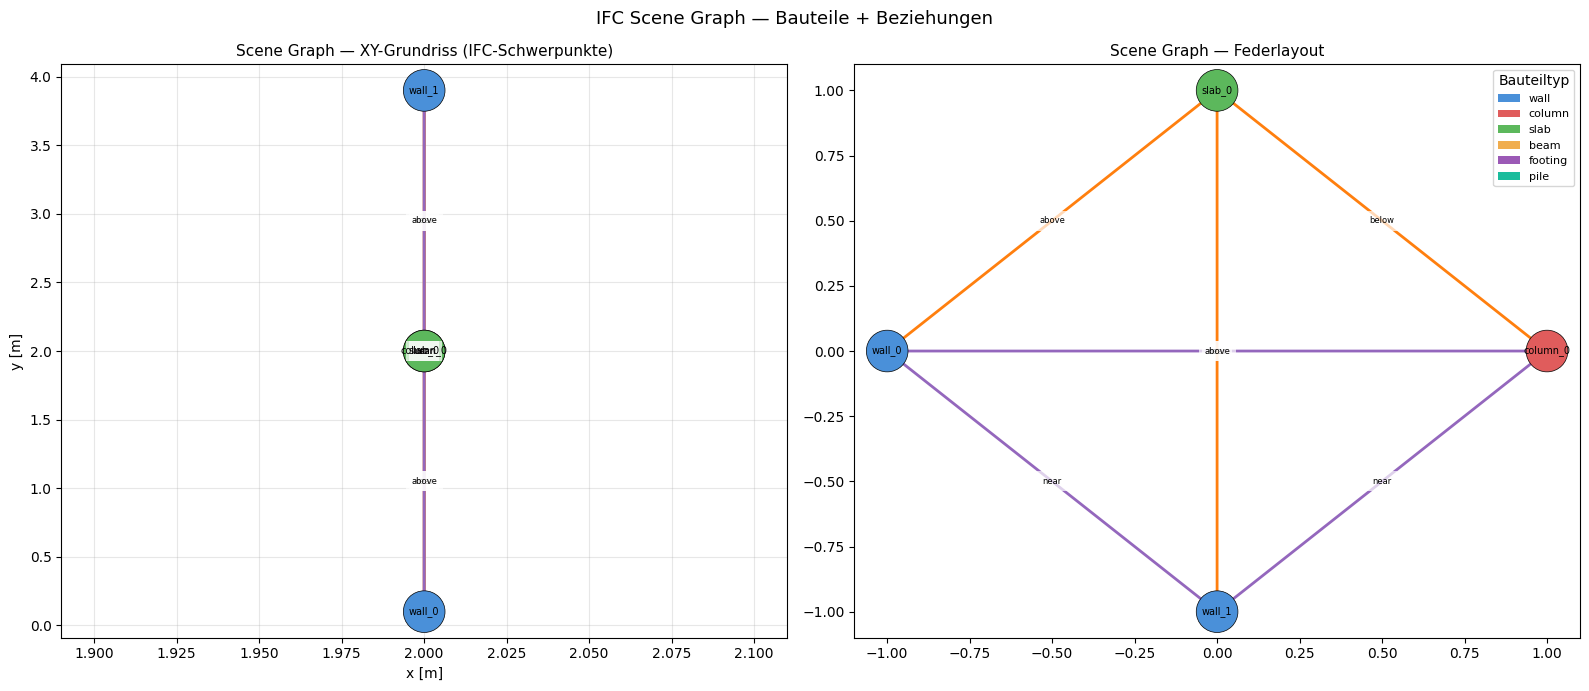

In [11]:
NODE_COLORS = {
    'wall'   : '#4a90d9', 'column': '#e05c5c',
    'slab'   : '#5cb85c', 'beam'  : '#f0ad4e',
    'footing': '#9b59b6', 'pile'  : '#1abc9c',
}
EDGE_COLORS = {
    'above'          : '#ff7f0e', 'below': '#ff7f0e',
    'adjacent'       : '#2ca02c', 'near' : '#9467bd',
    'inside'         : '#d62728', 'contains': '#d62728',
    'contains'       : '#17becf',
    'shared_material': '#8c564b',
    'hosted_in'      : '#e377c2',
}

# Layout: XY-Grundriss (Schwerpunkte)
pos_xy = {
    node: (data['centroid'][0], data['centroid'][1])
    for node, data in G.nodes(data=True)
}
pos_sp = nx.spring_layout(G, seed=42)

node_colors = [NODE_COLORS.get(G.nodes[n]['semantic_label'], '#aaa') for n in G.nodes]
edge_colors = [EDGE_COLORS.get(G.edges[e]['relationship'], '#888') for e in G.edges]
edge_labels = {e: G.edges[e]['relationship'] for e in G.edges}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

nx.draw_networkx(G, pos_xy, ax=axes[0], node_color=node_colors,
                 edge_color=edge_colors, node_size=900, font_size=7,
                 arrows=True, arrowsize=20, width=2)
nx.draw_networkx_edge_labels(G, pos_xy, edge_labels, font_size=6, ax=axes[0])
axes[0].set_title('Scene Graph — XY-Grundriss (IFC-Schwerpunkte)', fontsize=11)
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('y [m]')
axes[0].grid(True, alpha=0.3)

nx.draw_networkx(G, pos_sp, ax=axes[1], node_color=node_colors,
                 edge_color=edge_colors, node_size=900, font_size=7,
                 arrows=True, arrowsize=20, width=2)
nx.draw_networkx_edge_labels(G, pos_sp, edge_labels, font_size=6, ax=axes[1])
axes[1].set_title('Scene Graph — Federlayout', fontsize=11)

from matplotlib.patches import Patch
leg = [Patch(facecolor=c, label=l) for l, c in NODE_COLORS.items()]
axes[1].legend(handles=leg, title='Bauteiltyp', loc='upper right', fontsize=8)

plt.suptitle('IFC Scene Graph — Bauteile + Beziehungen', fontsize=13)
plt.tight_layout()
plt.show()

## 11 — Graphanalyse: Randbedingungen + Lastflächen

| Graph-Eigenschaft | FEM-Ableitung |
|---|---|
| `wall`/`column` ohne eingehende `below`-Kante | Einspannung am Fuß (z = z_min) |
| `slab` mit ausgehender `above`-Kante zu Wand/Stütze | Lastfläche oben |
| `slab` auf höchster z-Ebene | Primäre Lastauflagefläche |

In [12]:
def analyze_graph(G: nx.DiGraph) -> Dict:
    info = {
        'n_nodes'           : G.number_of_nodes(),
        'n_edges'           : G.number_of_edges(),
        'semantic_dist'     : {},
        'rel_types'         : {},
        'foundation_nodes'  : [],  # Einspannung
        'load_surface_nodes': [],  # Lastfläche
        'ifc_edge_count'    : 0,
        'geo_edge_count'    : 0,
    }
    for _, _, ed in G.edges(data=True):
        r = ed.get('relationship', '?')
        info['rel_types'][r] = info['rel_types'].get(r, 0) + 1
        if ed.get('source') == 'ifc': info['ifc_edge_count'] += 1
        else: info['geo_edge_count'] += 1

    for node, data in G.nodes(data=True):
        lbl = data['semantic_label']
        info['semantic_dist'][lbl] = info['semantic_dist'].get(lbl, 0) + 1

        # Einspannung: tragende Elemente ohne Auflager darunter
        if lbl in ('wall', 'column', 'footing'):
            has_support = any(
                G.edges[e]['relationship'] == 'below'
                for e in G.in_edges(node)
            )
            if not has_support:
                info['foundation_nodes'].append(node)

        # Lastfläche: Decken die über Wände/Stützen liegen
        if lbl == 'slab':
            bears_above = any(
                G.edges[e]['relationship'] in ('above', 'adjacent')
                for e in G.out_edges(node)
            )
            if bears_above:
                info['load_surface_nodes'].append(node)

    # Fallback: alle Decken als Lastfläche
    if not info['load_surface_nodes']:
        info['load_surface_nodes'] = [
            n for n, d in G.nodes(data=True) if d['semantic_label'] == 'slab'
        ]
    return info


sg_info = analyze_graph(G)

print('=== Scene-Graph-Analyse ===')
print(f'  Knoten / Kanten     : {sg_info["n_nodes"]} / {sg_info["n_edges"]}')
print(f'  IFC-Kanten          : {sg_info["ifc_edge_count"]}')
print(f'  Geometrische Kanten : {sg_info["geo_edge_count"]}')
print(f'  Semantik            : {sg_info["semantic_dist"]}')
print(f'  Beziehungstypen     : {sg_info["rel_types"]}')
print(f'\n  → FEM Einspannung   : {sg_info["foundation_nodes"]}')
print(f'  → FEM Lastfläche    : {sg_info["load_surface_nodes"]}')

=== Scene-Graph-Analyse ===
  Knoten / Kanten     : 4 / 6
  IFC-Kanten          : 0
  Geometrische Kanten : 6
  Semantik            : {'column': 1, 'slab': 1, 'wall': 2}
  Beziehungstypen     : {'below': 1, 'near': 3, 'above': 2}

  → FEM Einspannung   : ['column_0', 'wall_0', 'wall_1']
  → FEM Lastfläche    : ['slab_0']


### Visualisierung: Knotengrad + BC-Markierung

In [ ]:
# Visualisierung: Graphanalyse — Grad-Profil + BC-Markierung im Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Links: Knotengrad-Balken, farblich nach Rolle
nodes_list = list(G.nodes)
degrees    = {n: sum(1 for e in G.edges if n in e) for n in nodes_list}
bar_colors = []
bar_labels = []
for n in nodes_list:
    if n in sg_info['foundation_nodes']:
        bar_colors.append('#e05c5c'); bar_labels.append(f'{n}\n(Einspannung)')
    elif n in sg_info['load_surface_nodes']:
        bar_colors.append('#5cb85c'); bar_labels.append(f'{n}\n(Lastfläche)')
    else:
        bar_colors.append('#4a90d9'); bar_labels.append(n)

ax1 = axes[0]
xp = onp.arange(len(nodes_list))
ax1.bar(xp, [degrees[n] for n in nodes_list], color=bar_colors)
ax1.set_xticks(xp); ax1.set_xticklabels(bar_labels, fontsize=8)
ax1.set_ylabel('Graph-Grad (Anzahl Kanten)')
ax1.set_title('Knotengrad + FEM-Rolle', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color='#e05c5c', label='Einspannung (Fundament)'),
    Patch(color='#5cb85c', label='Lastfläche'),
    Patch(color='#4a90d9', label='Verbindungsknoten'),
], fontsize=8)

# Rechts: Scene Graph mit hervorgehobenen BC-Knoten (XZ-Ansicht)
ax2 = axes[1]
for key, obj in objects.items():
    col = '#e05c5c' if key in sg_info['foundation_nodes'] else \
          '#5cb85c' if key in sg_info['load_surface_nodes'] else '#4a90d9'
    cx, cz = obj['centroid'][0], obj['centroid'][2]
    ax2.scatter(cx, cz, s=200, c=col, zorder=4, edgecolors='black', lw=1.5)
    ax2.text(cx + 0.05, cz + 0.06, key, fontsize=7, zorder=5)

for o1, o2, rel in relationships:
    if o1 not in objects or o2 not in objects: continue
    x1, z1 = objects[o1]['centroid'][0], objects[o1]['centroid'][2]
    x2, z2 = objects[o2]['centroid'][0], objects[o2]['centroid'][2]
    ax2.plot([x1,x2],[z1,z2], color=EDGE_COLORS.get(rel,'#888'), lw=1.5, alpha=0.7)

ax2.set_xlabel('x [m]'); ax2.set_ylabel('z [m]')
ax2.set_title('BC-Knoten im Scene Graph (XZ)', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.legend(handles=[
    Patch(color='#e05c5c', label='Einspannung'),
    Patch(color='#5cb85c', label='Lastfläche'),
    Patch(color='#4a90d9', label='sonstige'),
], fontsize=8)

plt.suptitle('Graphanalyse → FEM-Randbedingungen', fontsize=12)
plt.tight_layout()
plt.show()

## 12 — Material-Mapping aus Scene Graph

Jeder Graphknoten liefert bereits E + ν aus dem IFC-Parsing (Schritt 3).  
Hier werden die Werte verifiziert und der effektive E-Modul für den Solver berechnet.

In [13]:
print(f'{"Knoten":18s}  {"Label":8s}  {"E [kN/m²]":>12s}  '
      f'{"ν":>6s}  Quelle')
print('-' * 60)

vol_sum  = 0.0
E_vol    = 0.0
nu_vol   = 0.0

for node, data in G.nodes(data=True):
    E_val = data['E_kNm2']
    nu_v  = data['nu']
    vol   = data['volume']
    src   = 'IFC' if E_val != E_DEFAULT else 'Fallback'
    print(f'  {node:16s}  {data["semantic_label"]:8s}  '
          f'{E_val:>12.0f}  {nu_v:>6.2f}  {src}')
    vol_sum += vol; E_vol += E_val * vol; nu_vol += nu_v * vol

E_eff  = E_vol  / vol_sum if vol_sum > 0 else E_DEFAULT
nu_eff = nu_vol / vol_sum if vol_sum > 0 else NU_DEFAULT
mu_eff    = E_eff / (2.0 * (1.0 + nu_eff))
lmbda_eff = E_eff * nu_eff / ((1.0 + nu_eff) * (1.0 - 2.0 * nu_eff))

print(f'\nVol.-gewichteter E_eff = {E_eff:.0f} kN/m²  '
      f'ν_eff = {nu_eff:.3f}')
print(f'μ = {mu_eff:.1f}  λ = {lmbda_eff:.1f}  (kN/m²)')

Knoten              Label        E [kN/m²]       ν  Quelle
------------------------------------------------------------
  column_0          column           35000    0.20  IFC
  slab_0            slab             30000    0.20  Fallback
  wall_0            wall             30000    0.20  Fallback
  wall_1            wall             30000    0.20  Fallback

Vol.-gewichteter E_eff = 30072 kN/m²  ν_eff = 0.200
μ = 12529.9  λ = 8353.3  (kN/m²)


### Visualisierung: E-Modul + Volumenanteil

In [ ]:
# Visualisierung: E-Modul + Volumen-Anteil pro Bauteil
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nodes_m = list(G.nodes)
E_vals  = [G.nodes[n]['E_kNm2']  for n in nodes_m]
nu_vals = [G.nodes[n]['nu']      for n in nodes_m]
vols    = [G.nodes[n]['volume']  for n in nodes_m]
cols_m  = [COLOR_MAP.get(G.nodes[n]['semantic_label'], '#aaa') for n in nodes_m]

ax1 = axes[0]
x_pos = onp.arange(len(nodes_m))
bars  = ax1.bar(x_pos, E_vals, color=cols_m, width=0.6)
ax1.axhline(E_eff, color='black', ls='--', lw=1.2,
            label=f'E_eff = {E_eff:.0f} kN/m²')
ax1.set_xticks(x_pos); ax1.set_xticklabels(nodes_m, rotation=15, ha='right', fontsize=8)
ax1.set_ylabel('E-Modul [kN/m²]'); ax1.set_title('E-Modul pro Bauteil', fontsize=10)
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, E_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 100,
             f'{val:.0f}', ha='center', va='bottom', fontsize=7)

ax2 = axes[1]
ax2.pie(vols, labels=nodes_m, colors=cols_m, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 8})
ax2.set_title(f'Volumen-Anteil (gesamt: {sum(vols):.2f} m³)', fontsize=10)

plt.suptitle('Material-Mapping aus IFC-PropertySets', fontsize=12)
plt.tight_layout()
plt.show()

## 13 — GMSH Tet4-Volumennetz aus Scene Graph

Die BBox jedes Graphknotens → `occ.addBox`.  
`occ.fragment` erzeugt gemeinsame Knoten an allen Kontaktflächen  
(Wand↔Decke, Stütze↔Decke → kein manuelles Node-Matching nötig).

In [14]:
def build_tet4_from_scene_graph(
    G: nx.DiGraph, mesh_size: float, out_msh: str
) -> Tuple[int, int]:
    if gmsh.isInitialized(): gmsh.finalize()
    gmsh.initialize()
    gmsh.option.setNumber('General.Terminal', 0)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMax', mesh_size)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMin', mesh_size * 0.1)
    gmsh.option.setNumber('Mesh.Algorithm3D', 4)
    gmsh.model.add('ifc_scene_graph')

    vol_tags = []
    for node, data in G.nodes(data=True):
        bmin = onp.array(data['bounds_min'])
        bmax = onp.array(data['bounds_max'])
        dims = bmax - bmin
        tag  = gmsh.model.occ.addBox(
            float(bmin[0]), float(bmin[1]), float(bmin[2]),
            float(dims[0]), float(dims[1]), float(dims[2]),
        )
        vol_tags.append(tag)

    gmsh.model.occ.synchronize()
    if len(vol_tags) > 1:
        all_v = [(3, t) for t in vol_tags]
        gmsh.model.occ.fragment(all_v, [])
        gmsh.model.occ.synchronize()

    vols = gmsh.model.getEntities(3)
    print(f'  GMSH: {len(vols)} Volumen → Vernetzung ...')
    gmsh.model.mesh.generate(3)
    gmsh.model.mesh.setOrder(1)
    try: gmsh.model.mesh.optimize('Netgen')
    except Exception: pass
    gmsh.write(str(out_msh))
    n_nodes = len(gmsh.model.mesh.getNodes()[0])
    n_tets  = len(gmsh.model.mesh.getElementsByType(4)[0])
    gmsh.finalize()
    return n_nodes, n_tets


msh_path = DATA_DIR / 'msh' / 'ifc_scene_graph.msh'
print('Starte GMSH Tet4-Vernetzung aus Scene Graph ...')
n_nodes, n_tets = build_tet4_from_scene_graph(G, MESH_SIZE, msh_path)
print(f'  Netz: {n_nodes} Knoten, {n_tets} Tet4-Elemente  (DOF: {n_nodes*3})')

raw      = meshio.read(str(msh_path))
points_m = raw.points
cells_m  = raw.cells_dict.get('tetra', onp.array([]))
if len(cells_m) == 0:
    raise RuntimeError('Keine Tet4-Elemente — GMSH-Fehler')

mesh     = Mesh(points_m, cells_m)
ele_type = 'TET4'
print(f'BBox: x [{points_m[:,0].min():.2f}, {points_m[:,0].max():.2f}]  '
      f'y [{points_m[:,1].min():.2f}, {points_m[:,1].max():.2f}]  '
      f'z [{points_m[:,2].min():.2f}, {points_m[:,2].max():.2f}]')

Starte GMSH Tet4-Vernetzung aus Scene Graph ...
  GMSH: 4 Volumen → Vernetzung ...
  Netz: 2178 Knoten, 6665 Tet4-Elemente  (DOF: 6534)

BBox: x [0.00, 4.00]  y [0.00, 4.00]  z [0.00, 3.00]


### Visualisierung: Netz-Querschnitte

In [ ]:
# Visualisierung: Netz-Querschnitte (Tet-Mittelpunkte)
tet_centroids = points_m[cells_m].mean(axis=1)   # (n_tets, 3)
y_mid = (points_m[:,1].min() + points_m[:,1].max()) / 2.0
y_tol = (points_m[:,1].max() - points_m[:,1].min()) / 5.0
mask_xz = onp.abs(tet_centroids[:,1] - y_mid) < y_tol

x_mid = (points_m[:,0].min() + points_m[:,0].max()) / 2.0
x_tol = (points_m[:,0].max() - points_m[:,0].min()) / 5.0
mask_yz = onp.abs(tet_centroids[:,0] - x_mid) < x_tol

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(tet_centroids[mask_xz, 0], tet_centroids[mask_xz, 2],
                s=1, c='#4a90d9', alpha=0.4)
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('z [m]')
axes[0].set_title(f'XZ-Schnitt — {mask_xz.sum()} Elemente', fontsize=10)
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.2)

axes[1].scatter(tet_centroids[mask_yz, 1], tet_centroids[mask_yz, 2],
                s=1, c='#e05c5c', alpha=0.4)
axes[1].set_xlabel('y [m]'); axes[1].set_ylabel('z [m]')
axes[1].set_title(f'YZ-Schnitt — {mask_yz.sum()} Elemente', fontsize=10)
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.2)

# Draufsicht (XY, Decke)
z_slab = points_m[:,2].max()
mask_xy = onp.abs(tet_centroids[:,2] - z_slab + MESH_SIZE/2) < MESH_SIZE
axes[2].scatter(tet_centroids[mask_xy, 0], tet_centroids[mask_xy, 1],
                s=1, c='#5cb85c', alpha=0.4)
axes[2].set_xlabel('x [m]'); axes[2].set_ylabel('y [m]')
axes[2].set_title(f'XY-Draufsicht Decke — {mask_xy.sum()} Elemente', fontsize=10)
axes[2].set_aspect('equal'); axes[2].grid(True, alpha=0.2)

plt.suptitle(f'Tet4-Netz: {n_nodes} Knoten, {n_tets} Elemente  '
             f'(h = {MESH_SIZE} m)', fontsize=12)
plt.tight_layout()
plt.show()

## 14 — Randbedingungen aus Scene Graph

Die Graphanalyse (Schritt 11) liefert automatisch:
- `foundation_nodes` → Einspannung am Fuß
- `load_surface_nodes` → Lastfläche oben

In [15]:
z_min = float(points_m[:, 2].min())
z_top = float(points_m[:, 2].max())
x_min = float(points_m[:, 0].min())
x_max = float(points_m[:, 0].max())
tol_bc = MESH_SIZE / 4.0

# Eigengewicht → Flächenlast auf Deckenoberkante
EG_kN = sum(
    GAMMA_BETON * d['volume']
    for _, d in G.nodes(data=True)
)
A_plan = (x_max - x_min) * (points_m[:,1].max() - points_m[:,1].min())
q_load = EG_kN / A_plan + Q_NUTZLAST

print(f'Eigengewicht   : {EG_kN:.1f} kN')
print(f'Grundrissfläche: {A_plan:.1f} m²')
print(f'Gesamtlast     : {q_load:.2f} kN/m²  (EG + {Q_NUTZLAST} kN/m² Nutzlast)')
print(f'z_min={z_min:.3f}   z_top={z_top:.3f}   tol_bc={tol_bc:.4f} m')

def zero(p): return 0.0

# Einspannung Fundamentebene
def at_base(p): return jnp.isclose(p[2], z_min, atol=tol_bc)

# Horizontale Stabilisierung (Symmetrielager x)
def at_x0(p): return jnp.isclose(p[0], x_min, atol=tol_bc)
def at_xL(p): return jnp.isclose(p[0], x_max, atol=tol_bc)

# Lastfläche oben (aus Graphanalyse: load_surface_nodes)
def at_top(p): return jnp.isclose(p[2], z_top, atol=tol_bc)

dirichlet_bc_info = [
    [at_base, at_base, at_base, at_x0, at_xL],
    [0,       1,       2,       0,     0    ],
    [zero,    zero,    zero,    zero,  zero ],
]
location_fns = [at_top]

n_base = int(onp.sum(onp.abs(points_m[:,2] - z_min) < tol_bc))
n_top  = int(onp.sum(onp.abs(points_m[:,2] - z_top) < tol_bc))
print(f'\nEinspannung z=0     : {n_base} Knoten')
print(f'Lastfläche z=z_top  : {n_top} Knoten')
print(f'Graph → Einspannung : {sg_info["foundation_nodes"]}')
print(f'Graph → Lastfläche  : {sg_info["load_surface_nodes"]}')

Eigengewicht   : 194.8 kN
Grundrissfläche: 16.0 m²
Gesamtlast     : 17.18 kN/m²  (EG + 5.0 kN/m² Nutzlast)
z_min=0.000   z_top=3.000   tol_bc=0.0625 m

Einspannung z=0     : 108 Knoten
Lastfläche z=z_top  : 340 Knoten
Graph → Einspannung : ['column_0', 'wall_0', 'wall_1']
Graph → Lastfläche  : ['slab_0']


### Visualisierung: Randbedingungen im Netz

In [ ]:
# Visualisierung: Randbedingungen im Netz
_mask_base  = onp.abs(points_m[:,2] - z_min) < tol_bc
_mask_top   = onp.abs(points_m[:,2] - z_top) < tol_bc
_mask_x0    = onp.abs(points_m[:,0] - x_min) < tol_bc
_mask_xL    = onp.abs(points_m[:,0] - x_max) < tol_bc
_mask_free  = ~(_mask_base | _mask_top | _mask_x0 | _mask_xL)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, x_col, z_col, xlabel, title in [
    (axes[0], 0, 2, 'x [m]', 'XZ — Randbedingungen'),
    (axes[1], 1, 2, 'y [m]', 'YZ — Randbedingungen'),
]:
    ax.scatter(points_m[_mask_free,  x_col], points_m[_mask_free,  z_col],
               s=1, c='#cccccc', alpha=0.3, label='frei')
    ax.scatter(points_m[_mask_base,  x_col], points_m[_mask_base,  z_col],
               s=4, c='#e05c5c', alpha=0.8, label=f'Einspannung z=0 ({_mask_base.sum()})')
    ax.scatter(points_m[_mask_top,   x_col], points_m[_mask_top,   z_col],
               s=4, c='#5cb85c', alpha=0.8, label=f'Last z=top ({_mask_top.sum()})')
    ax.scatter(points_m[_mask_x0,   x_col], points_m[_mask_x0,   z_col],
               s=4, c='#f0ad4e', alpha=0.8, label=f'Symm. x=0 ({_mask_x0.sum()})')
    ax.scatter(points_m[_mask_xL,   x_col], points_m[_mask_xL,   z_col],
               s=4, c='#f0ad4e', alpha=0.5, label=f'Symm. x=L ({_mask_xL.sum()})')
    ax.set_xlabel(xlabel); ax.set_ylabel('z [m]')
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7, markerscale=3)

plt.suptitle(f'Randbedingungen (aus Scene-Graph-Topologie) — {n_tets} Tet4', fontsize=12)
plt.tight_layout()
plt.show()

## 15 — JaxFEM-Solver (lineare 3D-Elastizität)

In [16]:
mu    = mu_eff
lmbda = lmbda_eff
q     = q_load


class IFC_SG_FEM(Problem):
    """Lineare 3D-Elastizität — IFC Scene Graph."""

    def get_tensor_map(self):
        def stress(u_grad):
            eps = 0.5 * (u_grad + u_grad.T)
            return lmbda * jnp.trace(eps) * jnp.eye(self.dim) + 2.0 * mu * eps
        return stress

    def get_surface_maps(self):
        def load_top(u, x):
            return jnp.array([0.0, 0.0, q])
        return [load_top]


problem = IFC_SG_FEM(
    mesh=mesh, vec=3, dim=3, ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)

print(f'Problem : {len(cells_m)} Tet4, {len(points_m)*3} DOF')
print(f'E_eff   : {E_eff:.0f} kN/m²   ν_eff: {nu_eff:.3f}')
print(f'Last q  : {q:.2f} kN/m²')
print('Löse (UMFPACK) ...')

sol   = solver(problem, solver_options={'umfpack_solver': {}})
ux    = onp.array(sol[0][:, 0])
uy    = onp.array(sol[0][:, 1])
uz    = onp.array(sol[0][:, 2])
u_abs = onp.sqrt(ux**2 + uy**2 + uz**2)

print(f'\nu_z_max (Absenkung) : {uz.min()*1000:.3f} mm')
print(f'|u|_max              : {u_abs.max()*1000:.3f} mm')
assert uz.min() < 0, 'Keine Absenkung — Lastvorzeichen prüfen!'

[04-25 18:38:11][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-25 18:38:11][DEBUG] jax_fem: ele_type = TET4, quad_points.shape = (num_quads, dim) = (1, 3)
[04-25 18:38:11][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 1, 3)
[04-25 18:38:12][DEBUG] jax_fem: Done pre-computations, took 0.4659922122955322 [s]
[04-25 18:38:12][INFO] jax_fem: Solving a problem with 6665 cells, 2178x3 = 6534 dofs.
[04-25 18:38:12][INFO] jax_fem: Element type is TET4, using 1 quad points per element.
[04-25 18:38:12][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-25 18:38:12][DEBUG] jax_fem: Start timing
[04-25 18:38:12][DEBUG] jax_fem: Computing cell Jacobian and cell residual...


Problem : 6665 Tet4, 6534 DOF
E_eff   : 30072 kN/m²   ν_eff: 0.200
Last q  : 17.18 kN/m²
Löse (UMFPACK) ...


[04-25 18:38:12][DEBUG] jax_fem: Function split_and_compute_cell took 0.1062 seconds
[04-25 18:38:13][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-25 18:38:13][DEBUG] jax_fem: Before, l_2 res = 15.456381076854063, relative l_2 res = 1.0
[04-25 18:38:13][DEBUG] jax_fem: Solving linear system...
[04-25 18:38:13][DEBUG] jax_fem: Scipy Solver - Solving linear system with UMFPACK
[04-25 18:38:13][DEBUG] jax_fem: Scipy Solver - Finished solving, linear solve res = 1.6421009002027036e-11
[04-25 18:38:13][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-25 18:38:13][DEBUG] jax_fem: Function split_and_compute_cell took 0.0028 seconds
[04-25 18:38:13][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-25 18:38:13][DEBUG] jax_fem: l_2 res = 1.6235777091187262e-11, relative l_2 res = 1.0504255174906592e-12
[04-25 18:38:13][INFO] jax_fem: Solve took 1.3285727500915527 [s]
[04-25 18:38:14][INFO] jax_fem: max of dofs = 0.04421264408388845
[04-25 18:38:14][INFO] jax_f


u_z_max (Absenkung) : -221.375 mm
|u|_max              : 221.376 mm


## 16 — Spannungsberechnung (Tet4)

In [17]:
def compute_stress_tet4(
    pts: onp.ndarray, cells: onp.ndarray,
    u_sol: onp.ndarray, lmbda: float, mu: float,
) -> onp.ndarray:
    sigma_gp, gp_coords = [], []
    for cell in cells:
        p  = pts[cell]
        ue = u_sol[cell]
        J  = p[1:4] - p[0]
        try: J_inv = onp.linalg.inv(J.T)
        except onp.linalg.LinAlgError: continue
        dN   = onp.array([[-1,-1,-1],[1,0,0],[0,1,0],[0,0,1]], dtype=float)
        dNdx = dN @ J_inv
        grad_u = ue.T @ dNdx
        eps    = 0.5 * (grad_u + grad_u.T)
        sig    = lmbda * onp.trace(eps) * onp.eye(3) + 2.0 * mu * eps
        sigma_gp.append([sig[0,0],sig[1,1],sig[2,2],
                         sig[0,1],sig[0,2],sig[1,2]])
        gp_coords.append(p.mean(axis=0))
    sigma_gp  = onp.array(sigma_gp)
    gp_coords = onp.array(gp_coords)
    _, idx = cKDTree(gp_coords).query(pts)
    return sigma_gp[idx]


sigma = compute_stress_tet4(points_m, cells_m,
                             onp.array(sol[0]), float(lmbda), float(mu))
s11, s22, s33 = sigma[:,0], sigma[:,1], sigma[:,2]
s12, s13, s23 = sigma[:,3], sigma[:,4], sigma[:,5]
s_vm = onp.sqrt(0.5 * ((s11-s22)**2 + (s22-s33)**2 + (s33-s11)**2
                       + 6*(s12**2 + s13**2 + s23**2)))

print(f'σ_33  : {s33.min():.1f} … {s33.max():.1f} kN/m²')
print(f'σ_vM max: {s_vm.max():.1f} kN/m²  ({s_vm.max()/1000:.3f} MN/m²)')

σ_33  : -2364.2 … 679.6 kN/m²
σ_vM max: 2255.7 kN/m²  (2.256 MN/m²)


### Visualisierung: Spannungs-Schnittbilder

In [ ]:
# Visualisierung: Matplotlib-Schnittbilder σ_zz + σ_vM + u_z
y_mid_pts = (points_m[:,1].min() + points_m[:,1].max()) / 2.0
y_tol_pts = (points_m[:,1].max() - points_m[:,1].min()) / 6.0
_xz = onp.abs(points_m[:,1] - y_mid_pts) < y_tol_pts

x_mid_pts = (points_m[:,0].min() + points_m[:,0].max()) / 2.0
x_tol_pts = (points_m[:,0].max() - points_m[:,0].min()) / 6.0
_yz = onp.abs(points_m[:,0] - x_mid_pts) < x_tol_pts

z_slab_pts = points_m[:,2].max()
_xy = onp.abs(points_m[:,2] - z_slab_pts) < tol_bc * 3

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def _splot(ax, pts, vals, xcol, zcol, xl, cmap, title, sym=False):
    vabs = onp.abs(vals).max()
    vmin = -vabs if sym else vals.min()
    vmax =  vabs if sym else vals.max()
    sc = ax.scatter(pts[:,xcol], pts[:,zcol], c=vals, cmap=cmap, s=2,
                    rasterized=True, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_xlabel(xl); ax.set_ylabel('z [m]')
    ax.set_title(title, fontsize=9); ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

# Zeile 1: XZ-Schnitt
_splot(axes[0,0], points_m[_xz], uz[_xz]*1000,   0, 2, 'x [m]', 'RdBu',   'u_z [mm] — XZ',   sym=True)
_splot(axes[0,1], points_m[_xz], s_vm[_xz],      0, 2, 'x [m]', 'plasma', 'σ_vM [kN/m²] — XZ')
_splot(axes[0,2], points_m[_xz], s33[_xz],       0, 2, 'x [m]', 'RdBu_r', 'σ_zz [kN/m²] — XZ', sym=True)

# Zeile 2: XY-Draufsicht Decke
if _xy.sum() > 0:
    _splot(axes[1,0], points_m[_xy], uz[_xy]*1000,      0, 1, 'x [m]', 'RdBu',    'u_z [mm] — Decke (Draufsicht)', sym=True)
    _splot(axes[1,1], points_m[_xy], s_vm[_xy],         0, 1, 'x [m]', 'plasma',  'σ_vM [kN/m²] — Decke')
    _splot(axes[1,2], points_m[_xy], u_abs[_xy]*1000,   0, 1, 'x [m]', 'viridis', '|u| [mm] — Decke')
    for ax in axes[1]: ax.set_ylabel('y [m]')
else:
    for ax in axes[1]: ax.set_visible(False)

plt.suptitle(f'Spannungen + Verformungen — IFC Scene Graph FEM  '
             f'(E_eff={E_eff:.0f} kN/m², q={q:.1f} kN/m²)', fontsize=11)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'vtk' / 'ifc_sg_fem_schnitte.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Schnitt-Plots gespeichert.')

## 17 — PyVista-Visualisierung

Warpfaktor: ×1


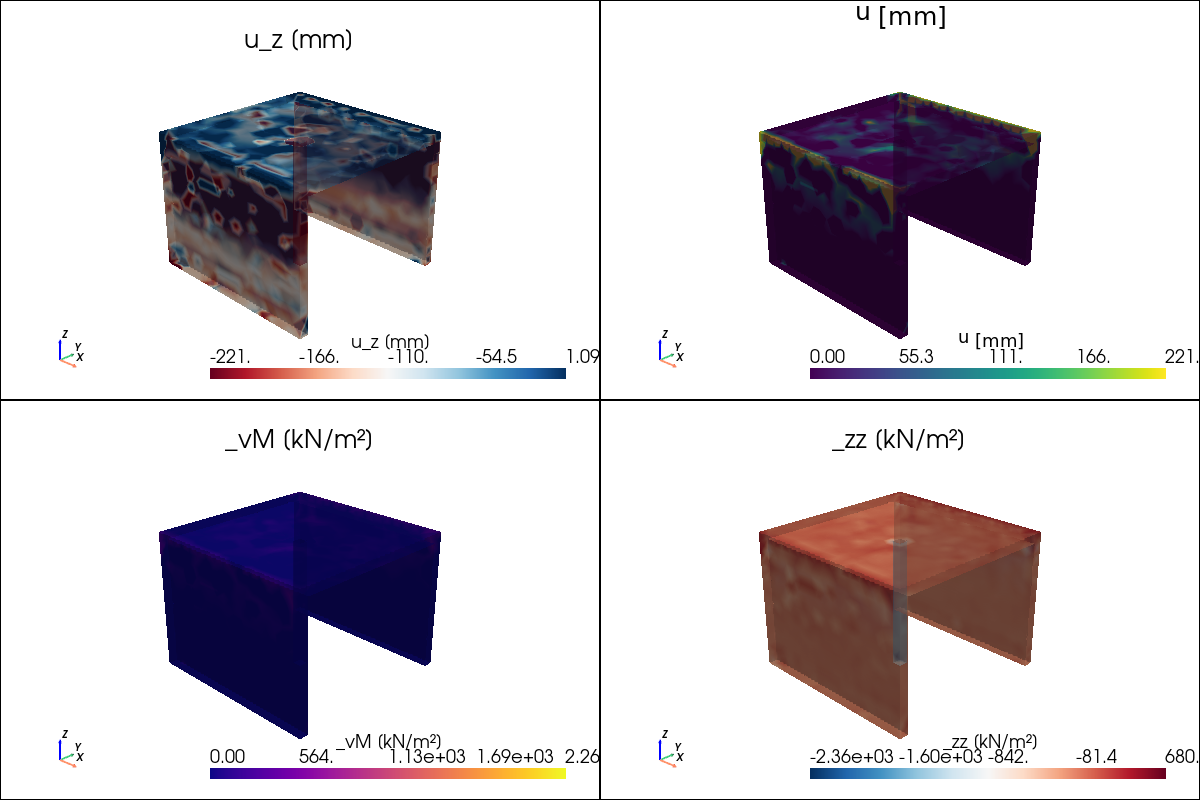

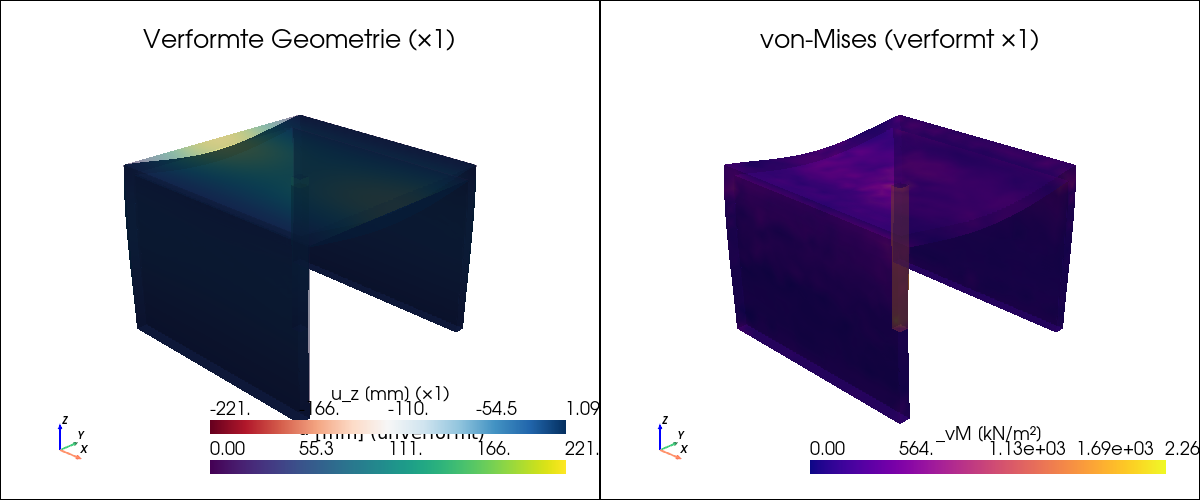

VTK gespeichert: ../data/vtk/ifc_sg_fem.vtu


In [22]:
pv.set_jupyter_backend('static')

cell_array = onp.hstack([
    onp.full((len(cells_m), 1), 4, dtype=onp.int64),
    cells_m.astype(onp.int64)
]).flatten()
cell_types = onp.full(len(cells_m), pv.CellType.TETRA)

grid = pv.UnstructuredGrid(cell_array, cell_types, points_m)
grid.point_data['uz_mm']    = uz * 1000
grid.point_data['u_abs_mm'] = u_abs * 1000
grid.point_data['sigma_vm'] = s_vm
grid.point_data['sigma_zz'] = s33

max_uz   = max(abs(uz.min()), abs(uz.max()))
char_len = float(points_m[:,2].max() - points_m[:,2].min())
warp_fac = max(round(min(0.05 * char_len / max(max_uz, 1e-12), 500.0)), 1)
print(f'Warpfaktor: ×{warp_fac}')

disp_vec = onp.column_stack([ux, uy, uz])
grid.point_data['displacement'] = disp_vec
warped = grid.warp_by_vector('displacement', factor=warp_fac)
warped.point_data['sigma_vm'] = s_vm
warped.point_data['uz_mm']    = uz * 1000

cam_pos = [(12, -8, 8), (2, 2, 1.5), (0, 0, 1)]

plotter = pv.Plotter(shape=(2, 2), window_size=(1200, 800), off_screen=True)
plotter.set_background('white')
for row, col, field, title, cmap in [
    (0, 0, 'uz_mm',    'u_z [mm]',     'RdBu'),
    (0, 1, 'u_abs_mm', '|u| [mm]',     'viridis'),
    (1, 0, 'sigma_vm', 'σ_vM [kN/m²]', 'plasma'),
    (1, 1, 'sigma_zz', 'σ_zz [kN/m²]', 'RdBu_r'),
]:
    plotter.subplot(row, col)
    plotter.add_mesh(grid, scalars=field, cmap=cmap, show_edges=False,
                     opacity=0.93, scalar_bar_args={'title': title})
    plotter.add_title(title, font_size=10)
    plotter.camera_position = cam_pos
    plotter.add_axes()
plotter.show(title=f'IFC → Scene Graph → JaxFEM  |  {len(cells_m)} Tet4')

# Warp-Plot
plotter2 = pv.Plotter(shape=(1, 2), window_size=(1200, 500), off_screen=True)
plotter2.set_background('white')
plotter2.subplot(0, 0)
plotter2.add_mesh(grid,   scalars='u_abs_mm', cmap='viridis', opacity=0.3, show_edges=False,
                  scalar_bar_args={'title': '|u| [mm] (unverformt)'})
plotter2.add_mesh(warped, scalars='uz_mm',    cmap='RdBu',    opacity=0.9, show_edges=False,
                  scalar_bar_args={'title': f'u_z [mm] (×{warp_fac})'})
plotter2.add_title(f'Verformte Geometrie (×{warp_fac})', font_size=10)
plotter2.camera_position = cam_pos; plotter2.add_axes()
plotter2.subplot(0, 1)
plotter2.add_mesh(warped, scalars='sigma_vm', cmap='plasma', opacity=0.95, show_edges=False,
                  scalar_bar_args={'title': 'σ_vM [kN/m²]'})
plotter2.add_title(f'von-Mises (verformt ×{warp_fac})', font_size=10)
plotter2.camera_position = cam_pos; plotter2.add_axes()
plotter2.show()

vtu_path = str(DATA_DIR / 'vtk' / 'ifc_sg_fem.vtu')
save_sol(problem.fes[0], sol[0], vtu_path)
print('VTK gespeichert:', vtu_path)

## 18 — FEM-Ergebnisse in Scene Graph zurückschreiben

Analog Poux & Lehtola (2025), Step 12:  
Jeder Knoten erhält `uz_min_mm`, `u_abs_max_mm`, `sigma_vm_max` aus dem FEM-Solver.

In [19]:
def write_fem_to_graph(
    G: nx.DiGraph, points_m, uz, u_abs, s_vm
) -> nx.DiGraph:
    for node, data in G.nodes(data=True):
        bmin = onp.array(data['bounds_min'])
        bmax = onp.array(data['bounds_max'])
        tol  = 1e-6
        mask = (
            (points_m[:,0] >= bmin[0]-tol) & (points_m[:,0] <= bmax[0]+tol) &
            (points_m[:,1] >= bmin[1]-tol) & (points_m[:,1] <= bmax[1]+tol) &
            (points_m[:,2] >= bmin[2]-tol) & (points_m[:,2] <= bmax[2]+tol)
        )
        if not mask.any():
            continue
        G.nodes[node]['uz_min_mm']    = round(float(uz[mask].min() * 1000), 3)
        G.nodes[node]['u_abs_max_mm'] = round(float(u_abs[mask].max() * 1000), 3)
        G.nodes[node]['sigma_vm_max'] = round(float(s_vm[mask].max()), 1)
    return G


G = write_fem_to_graph(G, points_m, uz, u_abs, s_vm)

print(f'{"Knoten":18s}  {"Label":8s}  '
      f'{"uz_min [mm]":>12s}  {"u_abs [mm]":>10s}  {"σ_vM_max":>10s}')
print('-' * 68)
for node, data in G.nodes(data=True):
    print(f'  {node:16s}  {data["semantic_label"]:8s}  '
          f'{data.get("uz_min_mm", 0.0):>12.3f}  '
          f'{data.get("u_abs_max_mm", 0.0):>10.3f}  '
          f'{data.get("sigma_vm_max", 0.0):>10.1f}')

# JSON-Export (Scene Graph + FEM-Ergebnisse)
sg_json = {
    'meta': {
        'description' : 'IFC Scene Graph FEM',
        'ifc_path'    : ifc_path,
        'mesh_size'   : MESH_SIZE,
        'n_elements'  : int(len(cells_m)),
        'n_nodes_fem' : int(len(points_m)),
        'E_eff_kNm2'  : round(float(E_eff), 1),
        'nu_eff'      : round(float(nu_eff), 4),
        'q_kNm2'      : round(float(q), 2),
        'units'       : 'kN + m',
    },
    'nodes': {
        node: {k: v for k, v in data.items() if not isinstance(v, onp.ndarray)}
        for node, data in G.nodes(data=True)
    },
    'edges': [
        {'from': u, 'to': v, 'relationship': d['relationship'],
         'source': d.get('source', 'geometric')}
        for u, v, d in G.edges(data=True)
    ],
}
json_path = DATA_DIR / 'ifc_scene_graph_fem.json'
with open(json_path, 'w', encoding='utf-8') as fh:
    json.dump(sg_json, fh, indent=2, ensure_ascii=False, default=str)
print(f'\nJSON gespeichert: {json_path}')

Knoten              Label      uz_min [mm]  u_abs [mm]    σ_vM_max
--------------------------------------------------------------------
  column_0          column        -150.130     150.140      2255.7
  slab_0            slab          -221.375     221.376      1566.6
  wall_0            wall           -24.046      45.179       823.8
  wall_1            wall           -23.474      44.998       872.3

JSON gespeichert: ../data/ifc_scene_graph_fem.json


### Visualisierung: Bauteil-Vergleich + Graph-Heatmap

In [ ]:
# Visualisierung: FEM-Ergebnisse pro Bauteil — Balkenvergleich + angereicherter Graph
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

nodes_r  = list(G.nodes)
cols_r   = [COLOR_MAP.get(G.nodes[n]['semantic_label'], '#aaa') for n in nodes_r]
uz_vals  = [G.nodes[n].get('uz_min_mm',    0.0) for n in nodes_r]
ua_vals  = [G.nodes[n].get('u_abs_max_mm', 0.0) for n in nodes_r]
sv_vals  = [G.nodes[n].get('sigma_vm_max', 0.0) for n in nodes_r]

def _bar(ax, vals, ylabel, title):
    xp = onp.arange(len(nodes_r))
    bars = ax.bar(xp, vals, color=cols_r, width=0.6)
    ax.set_xticks(xp)
    ax.set_xticklabels(
        [f'{n}\n({G.nodes[n]["semantic_label"]})' for n in nodes_r],
        fontsize=8, rotation=10, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(max(vals, key=abs)) * 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

_bar(axes[0], uz_vals,  'u_z_min [mm]',   'Maximale Absenkung')
_bar(axes[1], ua_vals,  '|u|_max [mm]',   'Maximale Verformung')
_bar(axes[2], sv_vals,  'σ_vM_max [kN/m²]','Max. von-Mises-Spannung')

plt.suptitle('FEM-Ergebnisse im Scene Graph — Bauteil-Vergleich', fontsize=12)
plt.tight_layout()
plt.show()

# --- Scene Graph mit FEM-Ergebnis-Heatmap ---
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

def _sg_heatmap(ax, attr, label, cmap_name, pos):
    import matplotlib.cm as cm
    vals_h = onp.array([G.nodes[n].get(attr, 0.0) for n in nodes_r])
    vmin_h, vmax_h = vals_h.min(), vals_h.max()
    norm_h = plt.Normalize(vmin=vmin_h, vmax=vmax_h)
    cmap_h = cm.get_cmap(cmap_name)
    for ni, node in enumerate(nodes_r):
        x, y = pos[node]
        col_h = cmap_h(norm_h(vals_h[ni]))
        ax.scatter(x, y, s=1200, c=[col_h], zorder=3, edgecolors='black', lw=1)
        ax.text(x, y, f'{node}\n{vals_h[ni]:.1f}', ha='center', va='center',
                fontsize=6, zorder=4)
    for o1, o2, ed in G.edges(data=True):
        x1, y1 = pos[o1]; x2, y2 = pos[o2]
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.5,
                                    mutation_scale=15), zorder=2)
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my, ed['relationship'], fontsize=6, color='#333',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))
    sm = plt.cm.ScalarMappable(cmap=cmap_h, norm=norm_h)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.7, label=label)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

_sg_heatmap(axes2[0], 'sigma_vm_max', 'σ_vM_max [kN/m²]', 'plasma', pos_xy)
axes2[0].set_title('Scene Graph — σ_vM Heatmap (XY)', fontsize=10)
axes2[0].set_xlabel('x [m]'); axes2[0].set_ylabel('y [m]')

_sg_heatmap(axes2[1], 'uz_min_mm', 'u_z_min [mm]', 'RdBu_r', pos_sp)
axes2[1].set_title('Scene Graph — u_z Heatmap (Federlayout)', fontsize=10)

plt.suptitle('FEM-Ergebnisse als Graph-Heatmap', fontsize=12)
plt.tight_layout()
plt.show()

## 19 — LLM-Prompt aus angereichertem Scene Graph

Der vollständige Graph (IFC-Relationships + Spatial + FEM-Ergebnisse)  
wird in einen strukturierten Textprompt für Spatial-AI-Abfragen umgewandelt.

In [20]:
def graph_to_llm_prompt(G: nx.DiGraph, uz, u_abs, s_vm, q) -> str:
    lines = [
        '=== IFC TRAGWERK — SCENE GRAPH + FEM-ERGEBNISSE ===',
        '',
        'BAUTEILE (Knoten):',
    ]
    for node, data in G.nodes(data=True):
        c = data.get('centroid', [0, 0, 0])
        lines.append(
            f'  [{node}]'
            f'  IFC={data.get("ifc_name", "?")} ({data.get("ifc_class","?")})'
            f'  Typ={data["semantic_label"]}'
            f'  Schwerpunkt=({c[0]:.1f}, {c[1]:.1f}, {c[2]:.1f}) m'
            f'  Volumen={data.get("volume", 0):.3f} m³'
            f'  E={data.get("E_kNm2", 0):.0f} kN/m²'
            f'  uz_min={data.get("uz_min_mm", 0):.3f} mm'
            f'  σ_vM_max={data.get("sigma_vm_max", 0):.1f} kN/m²'
        )
    lines += ['', 'BEZIEHUNGEN (Kanten):']
    for u_n, v_n, ed in G.edges(data=True):
        src = ed.get('source', 'geo')
        lines.append(f'  {u_n}  --[{ed["relationship"]} | {src}]-->  {v_n}')
    lines += [
        '',
        'FEM-ERGEBNISSE (Global):',
        f'  Max. Absenkung   : {uz.min()*1000:.3f} mm',
        f'  Max. Verformung  : {u_abs.max()*1000:.3f} mm',
        f'  Max. σ_vM        : {s_vm.max():.1f} kN/m²',
        f'  Gesamtlast       : {q:.2f} kN/m²',
        '',
        '==================================================',
    ]
    return '\n'.join(lines)


prompt = graph_to_llm_prompt(G, uz, u_abs, s_vm, q)
print(prompt)

# Beispiel-Fragen für Spatial AI
example_questions = [
    'Welches Bauteil ist strukturell am stärksten beansprucht?',
    'Wo liegt das Rissrisiko am höchsten (σ_vM)?',
    'Welche Bauteile sind direkt über der Stütze und tragen deren Last?',
    'Welche IFC-Relationships wurden automatisch erkannt?',
]

print('\n--- Beispiel-Abfragen für Spatial AI ---')
for q_example in example_questions:
    print(f'  → {q_example}')

print(f'\nLLM-Prompt bereit ({len(prompt)} Zeichen)')
print('  → client.messages.create(model="claude-sonnet-4-6", '
      'messages=[{"role":"user","content":prompt + "\\n\\nFRAGE: " + question}])')

=== IFC TRAGWERK — SCENE GRAPH + FEM-ERGEBNISSE ===

BAUTEILE (Knoten):
  [column_0]  IFC=Stuetze_M (IfcColumn)  Typ=column  Schwerpunkt=(2.0, 2.0, 1.4) m  Volumen=0.112 m³  E=35000 kN/m²  uz_min=-150.130 mm  σ_vM_max=2255.7 kN/m²
  [slab_0]  IFC=Decke_D1 (IfcSlab)  Typ=slab  Schwerpunkt=(2.0, 2.0, 2.9) m  Volumen=3.200 m³  E=30000 kN/m²  uz_min=-221.375 mm  σ_vM_max=1566.6 kN/m²
  [wall_0]  IFC=Wand_A (IfcWall)  Typ=wall  Schwerpunkt=(2.0, 0.1, 1.4) m  Volumen=2.240 m³  E=30000 kN/m²  uz_min=-24.046 mm  σ_vM_max=823.8 kN/m²
  [wall_1]  IFC=Wand_B (IfcWall)  Typ=wall  Schwerpunkt=(2.0, 3.9, 1.4) m  Volumen=2.240 m³  E=30000 kN/m²  uz_min=-23.474 mm  σ_vM_max=872.3 kN/m²

BEZIEHUNGEN (Kanten):
  column_0  --[below | geometric]-->  slab_0
  column_0  --[near | geometric]-->  wall_0
  column_0  --[near | geometric]-->  wall_1
  slab_0  --[above | geometric]-->  wall_0
  slab_0  --[above | geometric]-->  wall_1
  wall_0  --[near | geometric]-->  wall_1

FEM-ERGEBNISSE (Global):
  Max. Abse

## 20 — Zusammenfassung

| Schritt | Methode | Ergebnis |
|---------|---------|----------|
| 2 | IFC laden (Demo / eigene Datei) | IfcOpenShell, `Pset_MaterialMechanical` |
| 3 | Bauteil-Parsing + BBox + Material | `elements_raw` mit E, ν, BBox |
| 4 | Punktwolken-Visualisierung | XZ + YZ Schnittbilder |
| 5 | IFC-Relationship-Analyse | IfcRelAggregates, IfcRelAssociatesMaterial |
| 6 | Semantisches DBSCAN-Clustering | Objekt-Instanzen → IFC-Snap |
| 7 | Feature-Extraktion | Volumen, Höhe, Kompaktheit, Aspektverhältnis |
| 8 | Räumliche Beziehungsanalyse | above, adjacent, near |
| 9 | NetworkX DiGraph | Scene Graph (IFC + geometrisch) |
| 10 | Graph-Visualisierung | XY-Grundriss + Federlayout |
| 11 | Graph-Analyse | Randbedingungen + Lastflächen |
| 12 | Material-Mapping | E, ν aus IFC pro Knoten |
| 13 | GMSH Tet4-Netz | Aus BBox der Graphknoten |
| 14 | Randbedingungen | Aus Graphtopologie abgeleitet |
| 15 | JaxFEM-Solver | Lineare 3D-Elastizität |
| 16 | Spannungen | von-Mises, Voigt-Tensor |
| 17 | PyVista | 3D-Visualisierung + Warp |
| 18 | FEM → Graph | Ergebnisse in Graphknoten |
| 19 | LLM-Prompt | Abfragbarer Wissensgraph |

**Erweiterungen:**
- Echte IFC-Datei: `USE_DEMO_MODEL = False`, `IFC_PATH` setzen
- `IfcRelConnectsStructuralMember` → strukturelle Verbindungen als Kanten
- Bauteilweises heterogenes Materialfeld (subregionale JaxFEM-Probleme)
- OpenUSD-Export des angereicherten Scene Graphs
- LLM-Integration: Anthropic API `claude-sonnet-4-6`

In [21]:
print('=' * 60)
print('  IFC → Scene Graph → JaxFEM — Zusammenfassung')
print('=' * 60)
print(f'  IFC-Bauteile     : {len(elements_raw)}')
print(f'  Graph-Knoten     : {G.number_of_nodes()}')
print(f'  Graph-Kanten     : {G.number_of_edges()}  '
      f'(IFC:{sg_info["ifc_edge_count"]}  '
      f'Geo:{sg_info["geo_edge_count"]})')
print(f'  Tet4-Elemente    : {len(cells_m)}')
print(f'  Knoten / DOF     : {len(points_m)} / {len(points_m)*3}')
print(f'  E_eff / ν_eff    : {E_eff:.0f} kN/m²  /  {nu_eff:.2f}')
print(f'  Gesamtlast       : {q:.2f} kN/m²')
print('-' * 60)
print(f'  u_z_max          : {uz.min()*1000:.3f} mm')
print(f'  |u|_max          : {u_abs.max()*1000:.3f} mm')
print(f'  σ_vM_max         : {s_vm.max():.1f} kN/m²')
print(f'  σ_zz_min         : {s33.min():.1f} kN/m²  (Druckspannung)')
print('=' * 60)
print(f'  JSON             : {DATA_DIR / "ifc_scene_graph_fem.json"}')
print(f'  VTK              : {DATA_DIR / "vtk" / "ifc_sg_fem.vtu"}')
print('=' * 60)

  IFC → Scene Graph → JaxFEM — Zusammenfassung
  IFC-Bauteile     : 4
  Graph-Knoten     : 4
  Graph-Kanten     : 6  (IFC:0  Geo:6)
  Tet4-Elemente    : 6665
  Knoten / DOF     : 2178 / 6534
  E_eff / ν_eff    : 30072 kN/m²  /  0.20
  Gesamtlast       : 17.18 kN/m²
------------------------------------------------------------
  u_z_max          : -221.375 mm
  |u|_max          : 221.376 mm
  σ_vM_max         : 2255.7 kN/m²
  σ_zz_min         : -2364.2 kN/m²  (Druckspannung)
  JSON             : ../data/ifc_scene_graph_fem.json
  VTK              : ../data/vtk/ifc_sg_fem.vtu
